In [65]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error


In [66]:
team_Dream = ['Ralph', "Buddy", "Shaggy", "Tobias", "Susan", 
              "Jarod", "Tyson", "Caleb", "Syndrome", "Jimbo",
               "Wemby", "Journey", "Westbrook", "Anna", "Darryl" ]
team_Mean = ['Carl', "Jimmy", "Sheen", "Cindy", "Jimmy's mom", 
             "Mr. Crocker", "Timmy", "Cosmo", "Wanda", "Chip", 
             "Linda", "Link", "Ashley", "Shannon", "Denzel" ]
team_Together = team_Dream + team_Mean
team_Togetherdf = pd.DataFrame(team_Together, columns=['Player'])
team_Togetherdf["Team"] = ["Dream"] * len(team_Dream) + ["Mean"] * len(team_Mean)
team_Togetherdf["Alphas"] = np.random.normal(0, 5, len(team_Togetherdf))
# team_Togetherdf

In [67]:
# Get lineups and the strength of each lineup with 
# the sum of their Alphas
dream_lineup = np.random.choice(team_Dream, size=5, replace=False)
mean_lineup = np.random.choice(team_Mean, size=5, replace=False)

dream_strength = team_Togetherdf.loc[
    team_Togetherdf["Player"].isin(dream_lineup),
    "Alphas"
].sum()

mean_strength = team_Togetherdf.loc[
    team_Togetherdf["Player"].isin(mean_lineup),
    "Alphas"
].sum()

expected_margin = dream_strength - mean_strength


In [68]:
# include noise to simulate the variability in the game outcome
noise = np.random.normal(0, 3)

margin = expected_margin + noise

margin

#stints
stint = {
    "Dream Lineup": list(dream_lineup),
    "Mean Lineup": list(mean_lineup),
    "Margin": margin
}

print(stint)

{'Dream Lineup': [np.str_('Caleb'), np.str_('Syndrome'), np.str_('Anna'), np.str_('Journey'), np.str_('Wemby')], 'Mean Lineup': [np.str_('Ashley'), np.str_('Linda'), np.str_('Jimmy'), np.str_('Wanda'), np.str_('Cindy')], 'Margin': np.float64(-25.748885323391235)}


In [69]:
# Number of simulated stints
n_stints = 1000

# True player abilities
beta_true = team_Togetherdf["Alphas"].to_numpy()

# Map each player to a column in X
player_to_col = {
    player: i
    for i, player in enumerate(team_Togetherdf["Player"])
}

# Store each simulated stint
all_rows = []

for stint in range(n_stints):

    # Randomly choose 5 players from each team
    dream_lineup = np.random.choice(team_Dream, size=5, replace=False)
    mean_lineup = np.random.choice(team_Mean, size=5, replace=False)

    # One row of the design matrix
    row = np.zeros(len(team_Togetherdf))

    # Dream team gets +1
    for player in dream_lineup:
        row[player_to_col[player]] = 1

    # Mean team gets -1
    for player in mean_lineup:
        row[player_to_col[player]] = -1

    all_rows.append(row)

# Convert list of rows into a matrix
X = np.array(all_rows)

# Random error
epsilon = np.random.normal(0, 11, size=n_stints)

# Simulated point differentials
y = X @ beta_true + epsilon

# Fit the linear model
model = sm.OLS(y, X)
results = model.fit()

# Ridge regression
ridge = Ridge(alpha=1.0, fit_intercept=False)
ridge.fit(X, y)

beta_ridge = ridge.coef_

# Estimated player effects
beta_hat = results.params


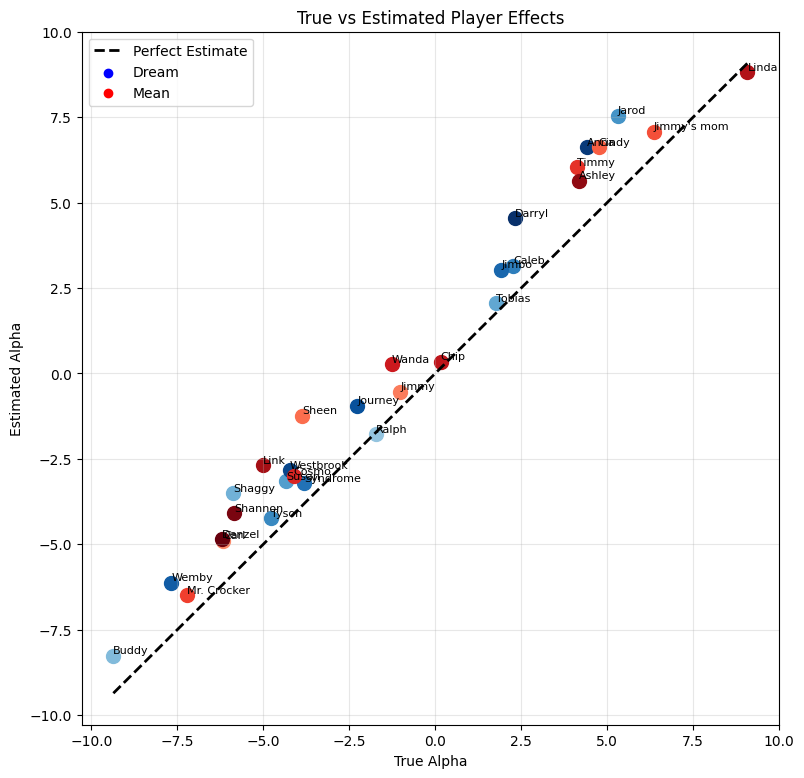

In [70]:
# graph the true beta values against the estimated beta values
plt.figure(figsize=(9,9))

# Colors for each team
dream_colors = plt.cm.Blues(np.linspace(0.4, 1, len(team_Dream)))
mean_colors = plt.cm.Reds(np.linspace(0.4, 1, len(team_Mean)))

# Plot Dream players
for i, player in enumerate(team_Dream):
    idx = player_to_col[player]

    plt.scatter(
        beta_true[idx],
        beta_hat[idx],
        color=dream_colors[i],
        s=100
    )

    plt.text(
        beta_true[idx],
        beta_hat[idx],
        player,
        fontsize=8,
        ha="left",
        va="bottom"
    )

# Plot Mean players
for i, player in enumerate(team_Mean):
    idx = player_to_col[player]

    plt.scatter(
        beta_true[idx],
        beta_hat[idx],
        color=mean_colors[i],
        s=100
    )

    plt.text(
        beta_true[idx],
        beta_hat[idx],
        player,
        fontsize=8,
        ha="left",
        va="bottom"
    )

# Perfect estimation line
low = min(beta_true.min(), beta_hat.min())
high = max(beta_true.max(), beta_hat.max())

plt.plot([low, high], [low, high], "k--", linewidth=2, label="Perfect Estimate")

plt.xlabel("True Alpha")
plt.ylabel("Estimated Alpha")
plt.title("True vs Estimated Player Effects")
plt.grid(alpha=0.3)

# Legend
plt.scatter([], [], color="blue", label="Dream")
plt.scatter([], [], color="red", label="Mean")
plt.legend()

plt.show()

Text(0, 0.5, 'Estimated Alpha')

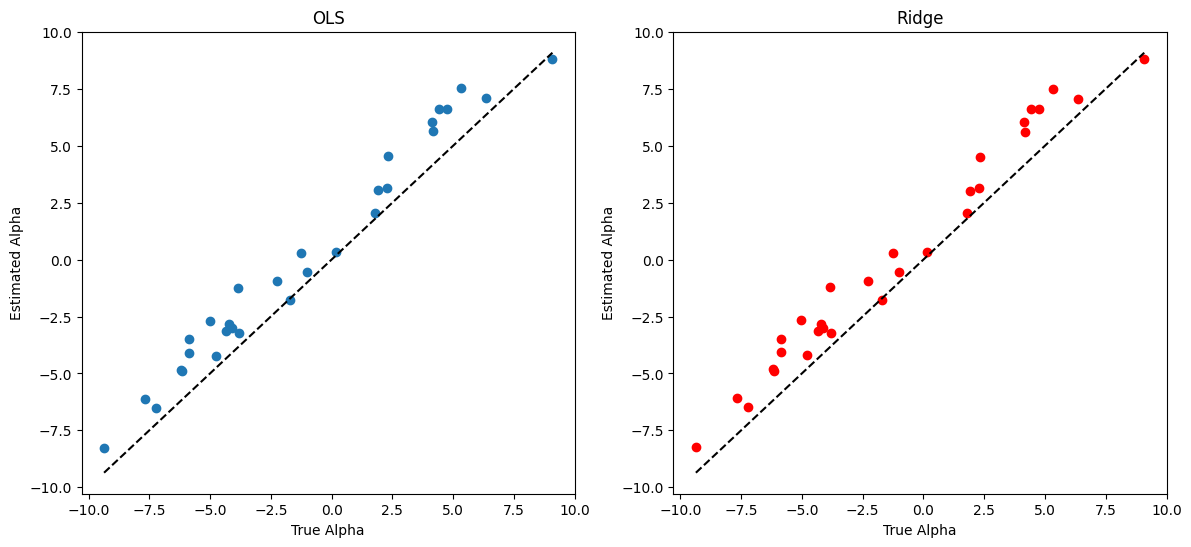

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# OLS
axes[0].scatter(beta_true, beta_hat)
axes[0].plot([low, high], [low, high], 'k--')
axes[0].set_title("OLS")
axes[0].set_xlabel("True Alpha")
axes[0].set_ylabel("Estimated Alpha")

# Ridge
axes[1].scatter(beta_true, beta_ridge, color="red")
axes[1].plot([low, high], [low, high], 'k--')
axes[1].set_title("Ridge")
axes[1].set_xlabel("True Alpha")
axes[1].set_ylabel("Estimated Alpha")

In [72]:
ols_rmse = np.sqrt(np.mean((beta_hat - beta_true)**2))
ridge_rmse = np.sqrt(np.mean((beta_ridge - beta_true)**2))

print(f"OLS RMSE   : {ols_rmse:.3f}")
print(f"Ridge RMSE : {ridge_rmse:.3f}")

OLS RMSE   : 1.473
Ridge RMSE : 1.473


In [73]:
from sklearn.linear_model import Ridge

# ==========================
# Simulation parameters
# ==========================

n_stints = 500

beta_true = team_Togetherdf["Alphas"].to_numpy()

player_to_col = {
    player: i
    for i, player in enumerate(team_Togetherdf["Player"])
}

# --------------------------
# Starting lineups
# --------------------------

dream_start = ["Ralph", "Buddy", "Shaggy", "Tobias", "Susan"]
dream_bench = ["Jarod", "Tyson", "Caleb", "Syndrome", "Jimbo"]

mean_start = ["Carl", "Jimmy", "Sheen", "Cindy", "Jimmy's mom"]
mean_bench = ["Mr. Crocker", "Timmy", "Cosmo", "Wanda", "Chip"]


def generate_lineup(starters, bench):
    """
    Generate one lineup by making 0-2 substitutions.
    """

    lineup = starters.copy()

    r = np.random.rand()

    # 70%: starters stay together
    if r < 0.70:
        return lineup

    # 20%: substitute one player
    elif r < 0.90:

        starter_out = np.random.choice(starters)
        bench_in = np.random.choice(bench)

        lineup.remove(starter_out)
        lineup.append(bench_in)

    # 10%: substitute two players
    else:

        starter_out = np.random.choice(starters, size=2, replace=False)
        bench_in = np.random.choice(bench, size=2, replace=False)

        for p in starter_out:
            lineup.remove(p)

        lineup.extend(list(bench_in))

    return lineup


# --------------------------
# Build X
# --------------------------

all_rows = []

for _ in range(n_stints):

    dream_lineup = generate_lineup(dream_start, dream_bench)
    mean_lineup = generate_lineup(mean_start, mean_bench)

    row = np.zeros(len(team_Togetherdf))

    for player in dream_lineup:
        row[player_to_col[player]] = 1

    for player in mean_lineup:
        row[player_to_col[player]] = -1

    all_rows.append(row)

X = np.array(all_rows)

# --------------------------
# Simulate scores
# --------------------------

epsilon = np.random.normal(0, 6, n_stints)

y = X @ beta_true + epsilon

# --------------------------
# OLS
# --------------------------

ols = sm.OLS(y, X)
ols_results = ols.fit()

beta_hat = ols_results.params

# --------------------------
# Ridge
# --------------------------

ridge = Ridge(alpha=10, fit_intercept=False)
ridge.fit(X, y)

beta_ridge = ridge.coef_

# --------------------------
# Compare RMSE
# --------------------------

ols_rmse = np.sqrt(np.mean((beta_hat - beta_true) ** 2))
ridge_rmse = np.sqrt(np.mean((beta_ridge - beta_true) ** 2))

print(f"OLS RMSE   : {ols_rmse:.3f}")
print(f"Ridge RMSE : {ridge_rmse:.3f}")

OLS RMSE   : 3.461
Ridge RMSE : 3.490


In [74]:
# ==========================
# SUMMARY STATISTICS
# SUBSTITUTION MODEL
# ==========================

print(ols_results.summary())

print("\nModel Performance")
print("-----------------")
print(f"OLS RMSE   : {ols_rmse:.3f}")
print(f"Ridge RMSE : {ridge_rmse:.3f}")

print("\nResponse Variable")
print("-----------------")
print(f"Mean margin : {np.mean(y):.2f}")
print(f"Std dev     : {np.std(y):.2f}")
print(f"Minimum     : {np.min(y):.2f}")
print(f"Maximum     : {np.max(y):.2f}")

appearances = np.sum(X != 0, axis=0)

summary_df = pd.DataFrame({
    "Player": team_Togetherdf["Player"],
    "Appearances": appearances,
    "True Alpha": beta_true,
    "OLS Estimate": beta_hat,
    "Ridge Estimate": beta_ridge
})

print("\nPlayer Summary")
print(summary_df)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.477
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     24.35
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.93e-56
Time:                        11:50:50   Log-Likelihood:                -1609.2
No. Observations:                 500   AIC:                             3256.
Df Residuals:                     481   BIC:                             3336.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.5206      0.906     -0.574      0.5

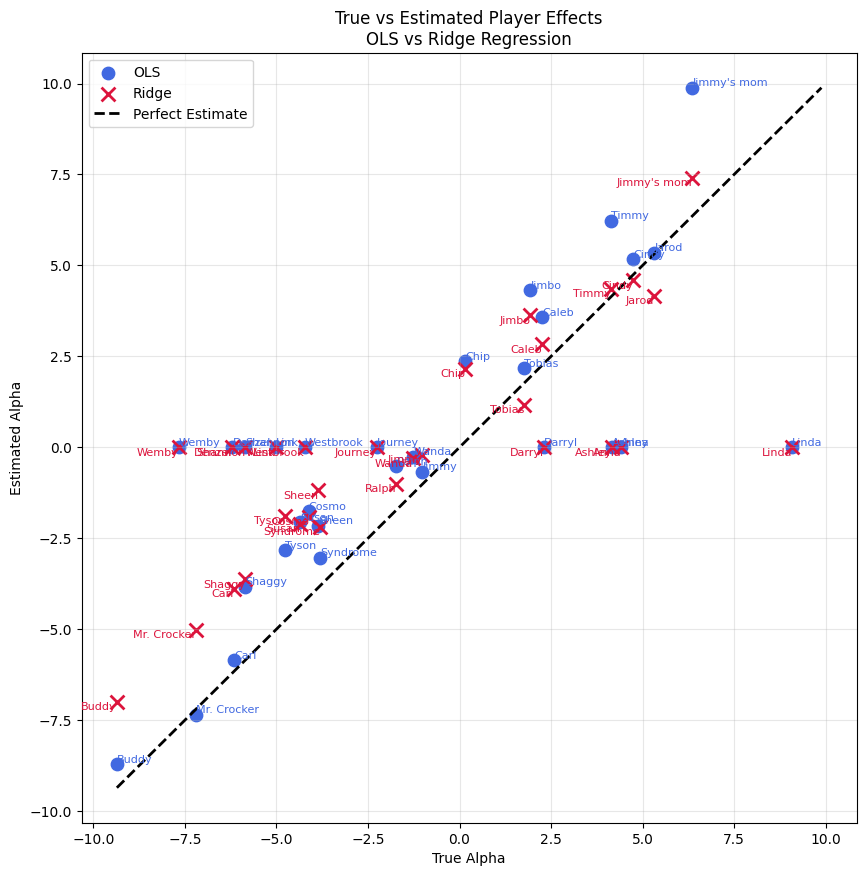

In [75]:
plt.figure(figsize=(10, 10))

# Plot OLS estimates
plt.scatter(
    beta_true,
    beta_hat,
    color="royalblue",
    s=80,
    label="OLS"
)

# Plot Ridge estimates
plt.scatter(
    beta_true,
    beta_ridge,
    color="crimson",
    marker="x",
    s=100,
    linewidth=2,
    label="Ridge"
)

# Label every player
for player in team_Together:
    idx = player_to_col[player]

    # OLS label
    plt.text(
        beta_true[idx],
        beta_hat[idx],
        player,
        fontsize=8,
        color="royalblue",
        ha="left",
        va="bottom"
    )

    # Ridge label (slightly offset)
    plt.text(
        beta_true[idx],
        beta_ridge[idx],
        player,
        fontsize=8,
        color="crimson",
        ha="right",
        va="top"
    )

# Perfect estimation line
low = min(beta_true.min(), beta_hat.min(), beta_ridge.min())
high = max(beta_true.max(), beta_hat.max(), beta_ridge.max())

plt.plot(
    [low, high],
    [low, high],
    "k--",
    linewidth=2,
    label="Perfect Estimate"
)

plt.xlabel("True Alpha")
plt.ylabel("Estimated Alpha")
plt.title("True vs Estimated Player Effects\nOLS vs Ridge Regression")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [76]:
# Assignment 1: No Interaction Ridge on an Interaction DGP
# This creates data where Ralph and Buddy have extra chemistry, 
# but the ridge model doesn't know about it.
# ==========================
# NO INTERACTION RIDGE
# ON INTERACTION DGP
# ==========================

# Create an interaction effect (Ralph + Buddy together)

interaction = (
    (X[:, player_to_col["Ralph"]] == 1) &
    (X[:, player_to_col["Buddy"]] == 1)
).astype(int)

gamma = 10      # strength of chemistry

epsilon = np.random.normal(0, 6, n_stints)

# Generate response WITH interaction
y_interaction = X @ beta_true + gamma * interaction + epsilon

# Fit Ridge WITHOUT interaction column
ridge_no_int = Ridge(alpha=10, fit_intercept=False)
ridge_no_int.fit(X, y_interaction)

beta_no_int = ridge_no_int.coef_

rmse_no_int = np.sqrt(np.mean((beta_no_int - beta_true)**2))

print("No Interaction Ridge on Interaction DGP")
print("---------------------------------------")
print(f"RMSE = {rmse_no_int:.3f}")

#Assignment 2: Interaction Ridge on an Interaction DGP
# this creates data where Ralph and Buddy have extra chemistry,
# and the ridge model knows about it.
# ==========================
# INTERACTION RIDGE
# ON INTERACTION DGP
# ==========================

# Same interaction variable
interaction = (
    (X[:, player_to_col["Ralph"]] == 1) &
    (X[:, player_to_col["Buddy"]] == 1)
).astype(int)

# Add interaction as a new predictor
X_inter = np.column_stack([X, interaction])

# True coefficients including interaction
beta_true_inter = np.append(beta_true, gamma)

# Fit Ridge WITH interaction column
ridge_int = Ridge(alpha=10, fit_intercept=False)
ridge_int.fit(X_inter, y_interaction)

beta_int = ridge_int.coef_

rmse_int = np.sqrt(np.mean((beta_int - beta_true_inter)**2))

print("Interaction Ridge on Interaction DGP")
print("------------------------------------")
print(f"RMSE = {rmse_int:.3f}")

print(f"\nEstimated interaction coefficient = {beta_int[-1]:.2f}")
print(f"True interaction coefficient      = {gamma:.2f}")

No Interaction Ridge on Interaction DGP
---------------------------------------
RMSE = 3.916
Interaction Ridge on Interaction DGP
------------------------------------
RMSE = 3.842

Estimated interaction coefficient = 3.36
True interaction coefficient      = 10.00


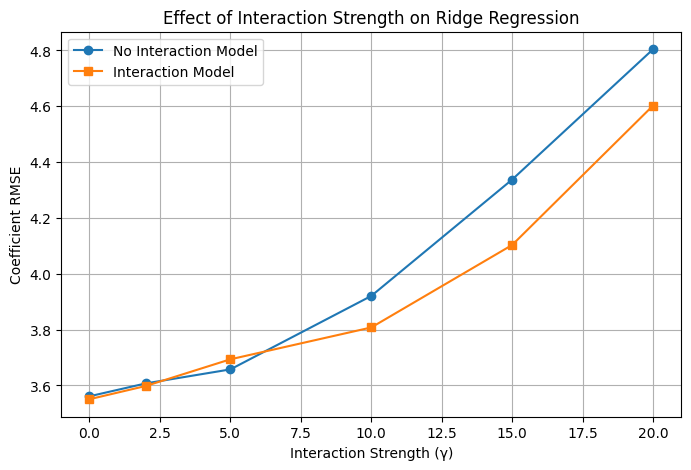

In [77]:
gammas = [0, 2, 5, 10, 15, 20]

rmse_no_int = []
rmse_with_int = []

for gamma in gammas:

    # Create interaction variable
    interaction = (
        (X[:, player_to_col["Ralph"]] == 1) &
        (X[:, player_to_col["Buddy"]] == 1)
    ).astype(int)

    # Simulate response
    epsilon = np.random.normal(0, 6, n_stints)
    y = X @ beta_true + gamma * interaction + epsilon

    # Ridge WITHOUT interaction
    ridge1 = Ridge(alpha=10, fit_intercept=False)
    ridge1.fit(X, y)

    beta1 = ridge1.coef_
    rmse1 = np.sqrt(np.mean((beta1 - beta_true)**2))

    # Ridge WITH interaction
    X_inter = np.column_stack([X, interaction])
    beta_true_inter = np.append(beta_true, gamma)

    ridge2 = Ridge(alpha=10, fit_intercept=False)
    ridge2.fit(X_inter, y)

    beta2 = ridge2.coef_
    rmse2 = np.sqrt(np.mean((beta2 - beta_true_inter)**2))

    rmse_no_int.append(rmse1)
    rmse_with_int.append(rmse2)

plt.figure(figsize=(8,5))
plt.plot(gammas, rmse_no_int, marker='o', label="No Interaction Model")
plt.plot(gammas, rmse_with_int, marker='s', label="Interaction Model")

plt.xlabel("Interaction Strength (γ)")
plt.ylabel("Coefficient RMSE")
plt.title("Effect of Interaction Strength on Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

In [78]:
gamma = 10
n_rep = 500

rmse_no = []
rmse_yes = []

interaction = (
    (X[:, player_to_col["Ralph"]] == 1) &
    (X[:, player_to_col["Buddy"]] == 1)
).astype(int)

X_inter = np.column_stack([X, interaction])
beta_true_inter = np.append(beta_true, gamma)

for rep in range(n_rep):

    epsilon = np.random.normal(0, 6, n_stints)
    y = X @ beta_true + gamma * interaction + epsilon

    ridge1 = Ridge(alpha=10, fit_intercept=False)
    ridge1.fit(X, y)

    ridge2 = Ridge(alpha=10, fit_intercept=False)
    ridge2.fit(X_inter, y)

    rmse_no.append(
        np.sqrt(np.mean((ridge1.coef_ - beta_true)**2))
    )

    rmse_yes.append(
        np.sqrt(np.mean((ridge2.coef_ - beta_true_inter)**2))
    )

print("Average over", n_rep, "simulations")
print("----------------------------------")
print(f"No interaction RMSE : {np.mean(rmse_no):.3f} ± {np.std(rmse_no):.3f}")
print(f"Interaction RMSE    : {np.mean(rmse_yes):.3f} ± {np.std(rmse_yes):.3f}")

Average over 500 simulations
----------------------------------
No interaction RMSE : 3.945 ± 0.067
Interaction RMSE    : 3.838 ± 0.066


In [79]:
bias = beta_no_int - beta_true

bias_df = pd.DataFrame({
    "Player": team_Togetherdf["Player"],
    "True Alpha": beta_true,
    "Estimated": beta_no_int,
    "Bias": bias
})

bias_df = bias_df.sort_values("Bias", key=np.abs, ascending=False)

print(bias_df)

         Player  True Alpha  Estimated      Bias
25        Linda    9.083031   0.000000 -9.083031
1         Buddy   -9.359855  -1.416716  7.943138
10        Wemby   -7.673937   0.000000  7.673937
0         Ralph   -1.723887   5.215453  6.939340
29       Denzel   -6.202968   0.000000  6.202968
28      Shannon   -5.857522   0.000000  5.857522
26         Link   -5.019249   0.000000  5.019249
13         Anna    4.416163   0.000000 -4.416163
12    Westbrook   -4.231066   0.000000  4.231066
27       Ashley    4.173749   0.000000 -4.173749
17        Sheen   -3.861589  -0.913038  2.948551
20  Mr. Crocker   -7.208226  -4.396743  2.811483
22        Cosmo   -4.116480  -1.790167  2.326314
14       Darryl    2.311312   0.000000 -2.311312
11      Journey   -2.265915   0.000000  2.265915
23        Wanda   -1.264584   0.907051  2.171635
16        Jimmy   -1.015904   0.947932  1.963836
15         Carl   -6.162880  -4.309680  1.853200
6         Tyson   -4.769445  -3.261486  1.507959
5         Jarod    5

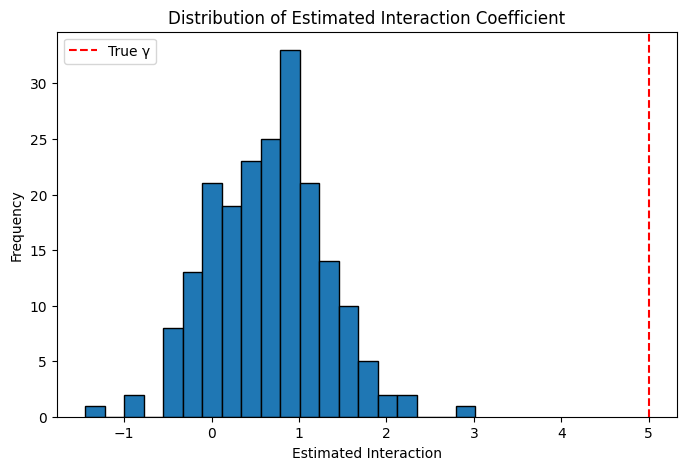

In [80]:
# Compare estimated interaction coefficient over many simulations
gamma = 5
n_rep = 200

interaction_estimates = []

interaction = (
    (X[:, player_to_col["Ralph"]] == 1) &
    (X[:, player_to_col["Buddy"]] == 1)
).astype(int)

X_inter = np.column_stack([X, interaction])

for rep in range(n_rep):

    epsilon = np.random.normal(0, 6, n_stints)
    y = X @ beta_true + gamma * interaction + epsilon

    ridge = Ridge(alpha=10, fit_intercept=False)
    ridge.fit(X_inter, y)

    interaction_estimates.append(ridge.coef_[-1])

plt.figure(figsize=(8,5))

plt.hist(interaction_estimates, bins=20, edgecolor="black")

plt.axvline(gamma, color="red", linestyle="--", label="True γ")

plt.xlabel("Estimated Interaction")
plt.ylabel("Frequency")
plt.title("Distribution of Estimated Interaction Coefficient")

plt.legend()
plt.show()


In [81]:
#Players regular season splits each team, 
# must play 11 games unless not enough reach the mark
# must end the season with the team
# I needed to add one for the kings who only had 14 eligble based on my rules, 
# I used my own discretion at times
# 25-26 season

# Western Conference
Thunder = [33, 29, 28, 27, 27,
           26, 24, 22, 21, 20,
           18, 18, 15, 12, 9]
Spurs = [31, 31, 30, 29, 28,
         26, 23, 23, 21, 13,
         12, 9, 7, 6, 6]
Nuggets = [35, 35, 32, 31, 30,
           28, 27, 24, 22, 16,
           15, 13, 12, 8, 8]
Lakers = [36, 35, 33, 29, 28,
          27, 25, 23, 18, 17,
          13, 11, 10, 9, 9]
Rockets = [37, 36, 35, 33, 26,
           26, 23, 17, 17, 14,
           12, 9, 8, 7, 6]
Timberwolves = [35, 33, 32, 31, 30,
                29, 26, 19, 18, 17,
                13, 13, 8, 7, 6]
Suns = [34, 30, 29, 29, 28,
        26, 24, 23, 22, 19,
        14, 14, 12, 10, 9]
Trailblazers = [33, 33, 30, 29, 29,
                27, 25, 23, 21, 19,
                19, 17, 16, 12, 12]
Clippers = [32, 29, 28, 27, 27,
            27, 22, 22, 20, 20,
            20, 18, 16, 10, 9]
Warriors = [31, 31, 29, 28, 26,
            24, 23, 22, 21, 20,
            19, 17, 17, 16, 16]
Pelicans = [36, 31, 30, 28, 26,
            25, 24, 21, 20, 16,
             15, 14, 13, 12, 8]
Mavericks = [34, 31, 30, 29, 22,
             22, 22, 21, 21, 20,
             15, 14, 14, 10, 10]
Grizzlies = [31, 29, 28, 26, 26,
             26, 25, 24, 24, 23,
             22, 21, 21, 21, 20]
Kings = [35, 31, 31, 30, 29,
         27, 26, 25, 24, 22,
          21, 18, 15, 13, 8]
Jazz = [34, 33, 28, 26, 26,
        26, 24, 24, 23, 23,
        21, 20, 17, 17, 14]

# Eastern Conference

Pistons = [34, 28, 28, 27, 26,
           23, 20, 20, 20, 19,
           18, 14, 12, 9, 8]
Celtics = [34, 34, 33, 32, 25,
           25, 21, 19, 18, 16,
           15, 11, 10, 7, 3]
Knicks = [35, 33, 33, 31, 30,
          26, 23, 20, 18, 17,
          11, 9, 9, 7, 7]
Cavaliers = [34, 34, 32, 27, 27,
             27, 25, 24, 22, 21,
             18, 16, 13, 12, 11]
Raptors = [34, 34, 32, 30, 25,
           23, 22, 22, 21, 14,
           9, 9, 6, 6, 5]
Hawks = [35, 33, 33, 31, 29,
         22, 22, 19, 18, 15,
          13, 11, 11, 10, 4]
Sixers = [38, 35, 32, 32, 31,
         29, 24, 20, 17, 17,
         16, 15, 14, 12, 8]
Magic = [35, 34, 30, 30, 29,
         28, 25, 20, 15, 13,
         13, 12, 12, 11, 10]
Hornets = [32, 31, 30, 28, 26,
           23, 21, 20, 19, 16,
           16, 16, 13, 12, 7]
Heat = [32, 31, 30, 30, 29,
        28, 26, 22, 18, 17,
        17, 16, 9, 9, 4]
Bucks = [33, 32, 29, 29, 27,
         27, 26, 24, 24, 21,
         20, 16, 14, 9, 4]
Bulls = [32, 29, 29, 27, 27,
          26, 25, 23, 22, 22,
          21, 12, 11, 10, 9]
Nets = [32, 28, 27, 25, 24,
        24, 23, 22, 21, 21,
        21, 21, 19, 19, 19]
Pacers = [33, 31, 30, 26, 25,
          24, 21, 20, 19, 18,
          18, 18, 17, 17, 13]
Wizards = [31, 29, 28, 27, 26,
           24, 22, 21, 20, 17,
           17, 17, 14, 10, 9]
nba_minutes = np.array([
    Hawks,
    Celtics,
    Nets,
    Hornets,
    Bulls,
    Cavaliers,
    Mavericks,
    Nuggets,
    Pistons,
    Warriors,
    Rockets,
    Pacers,
    Clippers,
    Lakers,
    Grizzlies,
    Heat,
    Bucks,
    Timberwolves,
    Pelicans,
    Knicks,
    Thunder,
    Magic,
    Sixers,
    Suns,
    Trailblazers,
    Kings,
    Spurs,
    Raptors,
    Jazz,
    Wizards
])




In [82]:
# Parameters
Nstint = 1000

# Generate player "abilities"
alpha = np.sort(np.random.normal(0, 3, 15))[::-1]
print(alpha)

# Softmax probabilities
probs = np.exp(alpha/3)
probs /= probs.sum()

# Count appearances
counts = np.zeros(15)

for _ in range(Nstint):
    # choose 5 players without replacement
    lineup = np.random.choice(15, size=5, replace=False, p=probs)

    players = np.zeros(15)
    players[lineup] = 1

    counts += players

# Fraction of stints
p = counts / Nstint

# Convert to expected minutes
minutes = np.round(p * 48).astype(int)

# Display as a 3x5 matrix
print(minutes.reshape(3, 5))

[ 6.49841029  2.35550992  2.30621826  2.22330497 -0.29786382 -0.49225644
 -1.18489228 -1.40793068 -2.58840499 -2.5886215  -3.45575138 -3.64091443
 -3.68473983 -3.68740254 -6.67117649]
[[47 32 31 31 18]
 [16 12 12  8  8]
 [ 7  6  6  5  2]]


In [83]:
# import numpy as np

# # ideal minutes
# target_minutes = np.array([36, 33, 26, 25, 24,
#                            22, 19, 14, 13, 8,
#                            7, 5, 4, 3, 1])

# if target_minutes.sum() != 240:
#     print("Target minutes must sum to 240.")
#     print(f"Sum of target minutes: {target_minutes.sum()}")

# best_rmse = np.inf
# best_sd = None
# best_Nstint = None
# best_minutes = None

# reps = 30
# adjust_values = np.arange(1, 5, .2)
# Nstint_values = [75, 100, 125, 150, 175, 200]

# for Nstint in Nstint_values:
#     for a in adjust_values:

#         total_rmse = 0
#         total_minutes = np.zeros(15)

#         for _ in range(reps):

#             # Generate player strengths
#             alpha = np.sort(np.random.normal(0, 3, 15))[::-1]

#             # Softmax probabilities
#             probs = np.exp(alpha/a)
#             probs /= probs.sum()

#             # Simulate all stints
#             lineups = np.array([
#                 np.random.choice(15, size=5, replace=False, p=probs)
#                 for _ in range(Nstint)
#             ])

#             # Count appearances
#             counts = np.bincount(lineups.ravel(), minlength=15)

#             # Convert to minutes
#             sim_minutes = np.round((counts / Nstint) * 48)

#             total_minutes += sim_minutes
#             total_rmse += np.sqrt(np.mean((sim_minutes - target_minutes) ** 2))

#         avg_rmse = total_rmse / reps
#         avg_minutes = np.round(total_minutes / reps)

#         if avg_rmse < best_rmse:
#             best_rmse = avg_rmse
#             best_adjust = a
#             best_Nstint = Nstint
#             best_minutes = avg_minutes.copy()

# print("=" * 40)
# print(f"Best Adjust: {best_adjust:.2f}")
# print(f"Best Nstint: {best_Nstint}")
# print(f"Average RMSE: {best_rmse:.2f}")

# print("\nBest Simulated Minutes:")
# print(best_minutes.reshape(3,5))

# print("\nTarget NBA Minutes:")
# print(target_minutes.reshape(3,5))

# print("\nDifference:")
# print((best_minutes - target_minutes).reshape(3,5))
# print("=" * 40)

In [84]:
target_minutes = np.array([[36, 33, 26, 25, 24],
                           [20, 17, 13, 14, 12],
                           [7, 5, 4, 3, 1]])

if target_minutes.sum() != 240:
    print("Target minutes must sum to 240.")
    print(f"Sum of target minutes: {target_minutes.sum()}")

In [85]:
# Reproducibility
np.random.seed(42)

# -----------------------------
# Settings
# -----------------------------
n = 1000          # number of games
sigma2 = 100      # numerator of the variance
lambda_ridge = 10 # Ridge penalty

# -----------------------------
# 1. Simulate possessions
# -----------------------------
# P_i ~ Poisson(3) + 1
P = np.random.poisson(lam=3, size=n) + 1

# -----------------------------
# 2. Simulate two explanatory variables
# -----------------------------
# Think of these as NBA team/game characteristics.
# Replace these with your actual NBA variables later.

X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)

# -----------------------------
# 3. Create the interaction
# -----------------------------
interaction = X1 * X2

# -----------------------------
# 4. Set the TRUE coefficients
# -----------------------------
beta0 = 2
beta1 = 5
beta2 = -3
beta3 = 4

# -----------------------------
# 5. Calculate the expected margin M_i
# -----------------------------
M = (
    beta0
    + beta1 * X1
    + beta2 * X2
    + beta3 * interaction
)

# -----------------------------
# 6. Generate the error
# -----------------------------
# E_i ~ N(0, 100 / P_i)
#
# np.random.normal takes standard deviation,
# so SD(E_i) = sqrt(100 / P_i)
#
E = np.random.normal(
    loc=0,
    scale=np.sqrt(sigma2 / P)
)

# -----------------------------
# 7. Generate observed outcome
# -----------------------------
# Y_i = M_i + E_i
Y = M + E

# -----------------------------
# Put everything into a DataFrame
# -----------------------------
df = pd.DataFrame({
    "Y": Y,
    "P": P,
    "X1": X1,
    "X2": X2,
    "interaction": interaction,
    "M_true": M,
    "E": E
})

print(df.head())

          Y  P        X1        X2  interaction    M_true         E
0 -1.487632  5  0.083481 -0.676241    -0.056453  4.220316 -5.707948
1 -0.911130  2 -0.519975 -1.094365     0.569042  4.959389 -5.870519
2  4.380231  4 -0.358766 -0.588154     0.211010  2.814672  1.565559
3 -2.475646  4 -0.081523  1.418239    -0.115619 -3.124806  0.649160
4  9.787211  3 -0.182418 -1.084210     0.197780  5.131658  4.655553


In [86]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=lambda_ridge)

ridge.fit(X, y)

print("\nRidge coefficients:")
print("Intercept:", ridge.intercept_)
print("X1:", ridge.coef_[0])
print("X2:", ridge.coef_[1])
print("Interaction:", ridge.coef_[2])


Ridge coefficients:
Intercept: -4.360571095006984
X1: 3.013782358339292
X2: -2.656196757487826
Interaction: -4.462841249507161


In [87]:
# Making Conferences and Individual Teams

team_Dream = ['Ralph', "Buddy", "Shaggy", "Bugs", "Susan", 
              "Jarod", "Jordan", "Dash", "Syndrome", "Jimbo",
               "Wemby", "Journey", "Westbrook", "Thomas The Train", "Darryl" ]
team_Mean = ['Carl', "Jimmy", "Sheen", "Cindy", "Jimmy's mom", 
             "Mr. Crocker", "Timmy", "Cosmo", "Wanda", "Chip", 
             "Violet", "Mr. P", "Wilson", "Shannon", "Denzel" ]
team_Toby = ["Toby", "Aric", 'Brooke', 'Adalee', 'Gideon', 
             "Adrain", "Tyson", "DDog", "Linda", "Link",
             "Ashley", "Tyler", "Raj", "Rush", "Hyrum"]
team_CalebP = ["CalebP", "Roland", "Handsome Jack", "Lilith", "Arthur Morgan",
               "John Marston", "Anthony Edwards", "Lamelo Ball", "Clap-Trap", "Rudy Gobert",
               "Ben", "Jansen", "Matt", "George Lombard Jr.", "Ben Rice"]
team_Daileysdogs = ['Dailey', "Darius Garland", "Brook Lopez", "Kris Dunn", "Rui Hachimura",
                    "Nathan Drake", "Victor Sullivan", "Free Sample Costco Employee", "Bradley Beal", "Mystery Girl",
                    "Nick", "Jared", "Dylan", "Master Chief", "Sarah" ]
team_Eli = ["Eli", "Mylee", "Yoshi", "Triple Decker", "Octane",
            "Fennec", "Dominus", "Mario", "Luigi", "Blue Toad",
            "Ore Port", "Wes", "Pyro", "Bobby", "Alec"]
team_NatesNarwals = ["Nate", "Narwhal", "Mr. Locksmith", "Defender", "Goalie",
                     "Attacker", "Centerback", "Right Wing", "Left Wing", "Messi",
                     "Nathan", "Nathaniel", "Big Nate", "Kareem", "Captain Hook"]
team_Jaxsyn = ["Jaxsyn", "Demar Defrozen", "Zach Lavine", "Russ", "Keegan Murray",
               "Trey Lyles", "Mike Brown's shadow", "Sabonis", "Deaaron Fox", "Shohei Ohtani",
               "Freddie Freeman", "Mookie Betts", "Blake Snell", "Clayton Kershaw", "Andy Pages"]
team_Anna = ["Anna", "Kelp", "Brooklyn", "Drew", "Hay Hay",
             "Ashley Wilson", "Evan", "Trey", "Ethan", "Tobias",
             "Joe", "Spencer", "Thomas", "Pink Taki's bag", "Elias"]
team_CalebB = ["CalebB", "Brynn", "Dame Dollar", "Deni Avdija", "Donovan Clingan",
               "Cal Raleigh", "Julio Rodriguez", "Bryan Woo", "Josh Naylor", "Logan Gilbert",
               "Whooly", "Frost", "Alley", "CJ Bott", "George Kirby"]


# =========================
# Sweet Candy Conference
# =========================

Sweet_Candy_Conference = {
    "Dream": team_Dream,
    "Mean": team_Mean,
    "Toby": team_Toby,
    "CalebP": team_CalebP,
    "DaileysDogs": team_Daileysdogs,
    "Eli": team_Eli,
    "NatesNarwals": team_NatesNarwals,
    "Jaxsyn": team_Jaxsyn,
    "Anna": team_Anna,
    "CalebB": team_CalebB
}

# Number of teams
num_teams = len(Sweet_Candy_Conference)

# Number of players per team
players_per_team = {
    team: len(players)
    for team, players in Sweet_Candy_Conference.items()
}

print("Sweet Candy Conference")
print("----------------------")
print(f"Number of teams: {num_teams}")
print()

for team, players in Sweet_Candy_Conference.items():
    print(f"{team}: {len(players)} players")


# ============================================================
# CREATE CONFERENCE SCHEDULE
# ============================================================

def create_schedule(conference):

    teams = list(conference.keys())

    schedule = []

    game_id = 0

    # Every team plays every other team twice
    for i in range(len(teams)):

        for j in range(i + 1, len(teams)):

            team_1 = teams[i]
            team_2 = teams[j]

            # First matchup
            schedule.append({
                "game_id": game_id,
                "home_team": team_1,
                "away_team": team_2
            })

            game_id += 1

            # Second matchup
            schedule.append({
                "game_id": game_id,
                "home_team": team_2,
                "away_team": team_1
            })

            game_id += 1

    return pd.DataFrame(schedule)


schedule_df = create_schedule(
    Sweet_Candy_Conference
)


print("\n")
print("SWEET CANDY CONFERENCE SCHEDULE")
print("--------------------------------------------")

print(
    schedule_df.to_string(
        index=False
    )
)

print(
    f"\nTotal games = {len(schedule_df)}"
)





Sweet Candy Conference
----------------------
Number of teams: 10

Dream: 15 players
Mean: 15 players
Toby: 15 players
CalebP: 15 players
DaileysDogs: 15 players
Eli: 15 players
NatesNarwals: 15 players
Jaxsyn: 15 players
Anna: 15 players
CalebB: 15 players


SWEET CANDY CONFERENCE SCHEDULE
--------------------------------------------
 game_id    home_team    away_team
       0        Dream         Mean
       1         Mean        Dream
       2        Dream         Toby
       3         Toby        Dream
       4        Dream       CalebP
       5       CalebP        Dream
       6        Dream  DaileysDogs
       7  DaileysDogs        Dream
       8        Dream          Eli
       9          Eli        Dream
      10        Dream NatesNarwals
      11 NatesNarwals        Dream
      12        Dream       Jaxsyn
      13       Jaxsyn        Dream
      14        Dream         Anna
      15         Anna        Dream
      16        Dream       CalebB
      17       CalebB        Drea

In [89]:
# Big Money Maker
# ============================================================
# NBA STINT SIMULATION
# REALISTIC ROTATIONS + OLS VS RIDGE
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import Ridge


# ============================================================
# 1. SETTINGS
# ============================================================

# Number of games
N_GAMES = 1000

# RIDGE_ALPHA will be determined automatically
# after the training/testing split

# ============================================================
# INTERACTION SETTINGS
# ============================================================

# Each tuple represents two players who have an interaction
# effect when they are BOTH on the court at the same time.

INTERACTION_PAIRS = [
    
    # Anna
    ("Ashley Wilson", "Brooklyn"),
    ("Anna", "Hay Hay"),

    # CalebB
    ("CalebB", "Julio Rodriguez"),
    ("Deni Avdija", "Whooly"),

    # CalebP
    ("Handsome Jack", "Rudy Gobert"),
    ("Ben Rice", "Ben"),

    # DaileysDogs
    ("Dailey", "Mystery Girl"),
    ("Darius Garland", "Brook Lopez"),

    # Dream
    ("Ralph", "Buddy"),
    ("Shaggy", "Bugs"),

    # Eli
    ("Eli", "Mylee"),
    ("Mario", "Yoshi"),

    # Jaxsyn
    ("Jaxsyn", "Demar Defrozen"),
    ("Shohei Ohtani", "Freddie Freeman"),

    # Mean
    ("Carl", "Jimmy"),
    ("Sheen", "Cindy"),
    
    # NatesNarwals
    ("Nate", "Narwhal"),
    ("Defender", "Attacker"),

    # Toby
    ("Toby", "Aric"),
    ("Brooke", "Adalee")
]


# ------------------------------------------------------------
# Give every interaction its own true effect
# ------------------------------------------------------------

interaction_strengths = {}

for pair in INTERACTION_PAIRS:

    interaction_strengths[pair] = np.random.normal(
        loc=0,
        scale=5
    )


print("\n")
print("TRUE INTERACTION EFFECTS")
print("--------------------------------------------")

for pair, strength in interaction_strengths.items():

    print(
        f"{pair[0]} + {pair[1]}: "
        f"{strength:.3f}"
    )

# ============================================================
# 3. ALL TEAMS / ALL PLAYERS
# ============================================================

all_players = []

for team, players in Sweet_Candy_Conference.items():
    all_players.extend(players)

player_to_col = {
    player: i
    for i, player in enumerate(all_players)
}

print(
    f"Total players in conference: "
    f"{len(all_players)}"
)


# ============================================================
# 4. TRUE PLAYER ALPHAS
# ============================================================

# Generate one true alpha for every player
# in the Sweet Candy Conference.
#
# Alphas ~ N(0, 5^2)

alpha_values = np.random.normal(
    0,
    5,
    len(all_players)
)


# Match each player to their true alpha

alpha_lookup = dict(
    zip(
        all_players,
        alpha_values
    )
)


# Create the true beta vector
# in the same order as all_players

beta_true = np.array([
    alpha_lookup[player]
    for player in all_players
])


# ============================================================
# CHECK ALPHAS
# ============================================================

print("\n")
print("TRUE PLAYER ALPHAS")
print("--------------------------------------------")

print(
    f"Number of players = {len(all_players)}"
)

print(
    f"Number of alphas = {len(beta_true)}"
)

print(
    f"Mean alpha = {beta_true.mean():.3f}"
)

print(
    f"SD alpha = {beta_true.std():.3f}"
)

# ============================================================
# 4b. CREATE TARGET MINUTES FROM ALPHAS
# ============================================================

# Each team has 15 players.
#
# Within each team:
# Highest alpha = most minutes
# Lowest alpha = fewest minutes
#
# Every team must have exactly 240 total player-minutes
# (5 players × 48 minutes)


def create_minutes_from_alphas(
    players,
    alpha_lookup,
    total_minutes=240
):

    # --------------------------------------------------------
    # Get alphas for these players
    # --------------------------------------------------------

    player_alphas = np.array([
        alpha_lookup[player]
        for player in players
    ])


    # --------------------------------------------------------
    # Sort players from highest alpha to lowest alpha
    # --------------------------------------------------------

    sorted_indices = np.argsort(
        -player_alphas
    )


    # --------------------------------------------------------
    # Base minutes by rank
    #
    # Rank 1 gets the most minutes
    # Rank 15 gets the fewest minutes
    # --------------------------------------------------------

    base_minutes = np.array([
        36, 33, 30, 27, 24,
        21, 18, 15, 12, 10,
         8,  6,  5,  3,  2
    ])


    # --------------------------------------------------------
    # Scale minutes so that every team has exactly
    # 240 total minutes
    # --------------------------------------------------------

    base_minutes = (
        base_minutes
        * total_minutes
        / base_minutes.sum()
    )


    base_minutes = np.round(
        base_minutes
    ).astype(int)


    # --------------------------------------------------------
    # Fix rounding
    # --------------------------------------------------------

    difference = (
        total_minutes
        -
        base_minutes.sum()
    )

    base_minutes[0] += difference


    # --------------------------------------------------------
    # Put minutes back into original player order
    # --------------------------------------------------------

    minutes = np.zeros(
        len(players),
        dtype=int
    )


    for rank, player_index in enumerate(
        sorted_indices
    ):

        minutes[player_index] = (
            base_minutes[rank]
        )


    return minutes


# ============================================================
# CREATE TARGET MINUTES FOR EVERY TEAM
# ============================================================

team_minutes = {}

for team, players in Sweet_Candy_Conference.items():

    team_minutes[team] = (
        create_minutes_from_alphas(
            players,
            alpha_lookup
        )
    )


# ============================================================
# CREATE A COMPLETE MINUTES TABLE
# ============================================================

minutes_rows = []

for team, players in Sweet_Candy_Conference.items():

    for i, player in enumerate(players):

        minutes_rows.append({

            "Team":
                team,

            "Player":
                player,

            "Alpha":
                alpha_lookup[player],

            "Target_Minutes":
                team_minutes[team][i]
        })


minutes_df = pd.DataFrame(
    minutes_rows
)


# ============================================================
# SORT BY TEAM AND ALPHA
# ============================================================

minutes_df = minutes_df.sort_values(
    ["Team", "Alpha"],
    ascending=[True, False]
)


# ============================================================
# DISPLAY MINUTES
# ============================================================

print("\n")
print("TARGET MINUTES BY TEAM")
print("--------------------------------------------")

print(
    minutes_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)


# ============================================================
# CHECK TOTAL MINUTES FOR EACH TEAM
# ============================================================

print("\n")
print("TEAM MINUTE TOTALS")
print("--------------------------------------------")

team_minute_totals = (
    minutes_df
    .groupby("Team")["Target_Minutes"]
    .sum()
)

print(
    team_minute_totals
)


# ============================================================
# COMBINE ALL TEAM MINUTES INTO ONE VECTOR
# ============================================================

target_minutes = np.concatenate([
    team_minutes[team]
    for team in Sweet_Candy_Conference.keys()
])


# ============================================================
# 5. ROTATION GENERATOR
#
# Creates 48 valid lineups.
#
# Players remain on the floor when possible.
# Players with more minutes remaining receive priority.
# This creates much longer stints than the previous method.
# ============================================================

def generate_rotation(target_minutes):

    remaining = target_minutes.copy()
    rotation = []

    # ========================================================
    # HELPER FUNCTION
    # Choose a lineup while trying to satisfy remaining minutes
    # ========================================================

    def choose_lineup(current_lineup, remaining, preferred_players=None):

        lineup = []

        if preferred_players is None:
            preferred_players = []

        # ----------------------------------------------------
        # Players who absolutely need to play
        # ----------------------------------------------------

        minutes_left = max(
            48 - len(rotation),
            1
        )

        must_play = []

        for player in range(15):

            if remaining[player] >= minutes_left:
                must_play.append(player)

        # Add must-play players first
        for player in must_play:
            if len(lineup) < 5:
                lineup.append(player)

        # ----------------------------------------------------
        # Give preferred players a bonus
        # ----------------------------------------------------

        candidates = []

        for player in range(15):

            if player in lineup:
                continue

            if remaining[player] <= 0:
                continue

            # Need for minutes
            urgency = (
                remaining[player]
                /
                max(minutes_left, 1)
            )

            # Staying on court is preferred
            if player in current_lineup:
                overlap_bonus = 2.0
            else:
                overlap_bonus = 0.0

            # Preferred players get an additional bonus
            if player in preferred_players:
                preference_bonus = 1.5
            else:
                preference_bonus = 0.0

            # Randomness
            random_component = np.random.uniform(
                0,
                0.25
            )

            score = (
                urgency
                +
                overlap_bonus
                +
                preference_bonus
                +
                random_component
            )

            candidates.append(
                (
                    player,
                    score
                )
            )

        candidates.sort(
            key=lambda x: x[1],
            reverse=True
        )

        # Fill lineup
        for player, score in candidates:

            if len(lineup) >= 5:
                break

            lineup.append(player)

        return lineup


    # ========================================================
    # STARTING LINEUP
    # ========================================================

    starters = list(
        np.argsort(-remaining)[:5]
    )

    current_lineup = starters.copy()

    # Remove first minute
    for player in current_lineup:
        remaining[player] -= 1

    rotation.append(
        tuple(sorted(current_lineup))
    )


    # ========================================================
    # SUBSTITUTION PLAN
    #
    # These are approximate game times.
    # ========================================================

    substitution_times = [

        # ---------------- FIRST HALF ----------------

        np.random.randint(6, 9),      # First sub: 6-8

        np.random.randint(8, 11),     # Around 8-10

        np.random.randint(10, 13),    # Around 10-12

        np.random.randint(12, 15),    # Early 2nd quarter

        np.random.randint(15, 18),    # Middle 2nd quarter

        np.random.randint(18, 21),    # Starters return

        np.random.randint(21, 24),    # Closing lineup


        # ---------------- SECOND HALF ----------------

        24 + np.random.randint(6, 9),

        24 + np.random.randint(8, 11),

        24 + np.random.randint(10, 13),

        24 + np.random.randint(12, 15),

        24 + np.random.randint(15, 18),

        24 + np.random.randint(18, 21),

        24 + np.random.randint(21, 24)
    ]


    # ========================================================
    # GO THROUGH THE GAME MINUTE BY MINUTE
    # ========================================================

    for minute in range(1, 48):

        game_time = minute

        # ----------------------------------------------------
        # HALFTIME
        #
        # Give starters a chance to return to the lineup
        # after halftime.
        # ----------------------------------------------------

        if game_time == 24:

            # Start second half with starters
            preferred_players = starters

            new_lineup = choose_lineup(
                current_lineup,
                remaining,
                preferred_players
            )

        # ----------------------------------------------------
        # SUBSTITUTION TIME
        # ----------------------------------------------------

        elif game_time in substitution_times:

            # ------------------------------------------------
            # Late in each half:
            # favor the starters / high-minute players
            # ------------------------------------------------

            if (
                game_time >= 18
                and
                game_time < 24
            ) or game_time >= 42:

                preferred_players = starters

            else:

                preferred_players = []

            new_lineup = choose_lineup(
                current_lineup,
                remaining,
                preferred_players
            )

        # ----------------------------------------------------
        # NO SUBSTITUTION
        #
        # Keep the same five players.
        # ----------------------------------------------------

        else:

            new_lineup = current_lineup.copy()


        # ----------------------------------------------------
        # Make sure we have exactly five players
        # ----------------------------------------------------

        if len(new_lineup) < 5:

            available = [
                p
                for p in range(15)
                if (
                    p not in new_lineup
                    and
                    remaining[p] > 0
                )
            ]

            available.sort(
                key=lambda p: remaining[p],
                reverse=True
            )

            for player in available:

                if len(new_lineup) >= 5:
                    break

                new_lineup.append(player)


        # ----------------------------------------------------
        # Remove one minute from players on court
        # ----------------------------------------------------

        for player in new_lineup:
            remaining[player] -= 1


        # ----------------------------------------------------
        # Save lineup
        # ----------------------------------------------------

        current_lineup = new_lineup.copy()

        rotation.append(
            tuple(
                sorted(current_lineup)
            )
        )


    return rotation


# ============================================================
# 6. TURN LINEUP CHANGES INTO STINTS
# ============================================================

def create_stints(
    home_rotation,
    away_rotation
):

    stints = []

    current_home = home_rotation[0]
    current_away = away_rotation[0]

    stint_start = 0

    for minute in range(1, 48):

        home_changed = (
            home_rotation[minute]
            != current_home
        )

        away_changed = (
            away_rotation[minute]
            != current_away
        )

        # A stint ends when either team substitutes
        if home_changed or away_changed:

            stints.append({

                "start_minute":
                    stint_start,

                "end_minute":
                    minute,

                "minutes":
                    minute - stint_start,

                "home_lineup":
                    current_home,

                "away_lineup":
                    current_away
            })

            current_home = (
                home_rotation[minute]
            )

            current_away = (
                away_rotation[minute]
            )

            stint_start = minute

    # Final stint
    stints.append({

        "start_minute":
            stint_start,

        "end_minute":
            48,

        "minutes":
            48 - stint_start,

        "home_lineup":
            current_home,

        "away_lineup":
            current_away
    })

    return stints


# ============================================================
# 7. CREATE X ROW
# ============================================================

def create_X_row(
    home_lineup,
    away_lineup,
    home_team,
    away_team
):

    # Start with 150 zeros
    row = np.zeros(
        len(all_players)
    )


    # ========================================================
    # HOME TEAM
    # ========================================================

    home_players = Sweet_Candy_Conference[
        home_team
    ]

    for player_index in home_lineup:

        player = home_players[
            player_index
        ]

        column = player_to_col[
            player
        ]

        row[column] = 1


    # ========================================================
    # AWAY TEAM
    # ========================================================

    away_players = Sweet_Candy_Conference[
        away_team
    ]

    for player_index in away_lineup:

        player = away_players[
            player_index
        ]

        column = player_to_col[
            player
        ]

        row[column] = -1


    return row



# ============================================================
# CREATE INTERACTION VALUES
# ============================================================

def create_interaction_values(
    home_lineup,
    away_lineup,
    home_team,
    away_team
):

    interaction_values = []

    # --------------------------------------------------------
    # Get actual player names on the court
    # --------------------------------------------------------

    home_players = Sweet_Candy_Conference[home_team]
    away_players = Sweet_Candy_Conference[away_team]

    players_on_court = set()

    for player_index in home_lineup:

        players_on_court.add(
            home_players[player_index]
        )

    for player_index in away_lineup:

        players_on_court.add(
            away_players[player_index]
        )


    # --------------------------------------------------------
    # Check every interaction pair
    # --------------------------------------------------------

    for pair in INTERACTION_PAIRS:

        player_1 = pair[0]
        player_2 = pair[1]

        # Both players must be on the court
        if (
            player_1 in players_on_court
            and
            player_2 in players_on_court
        ):

            interaction_values.append(1)

        else:

            interaction_values.append(0)


    return np.array(
        interaction_values
    )


# ============================================================
# 8. SIMULATE ONE GAME
# ============================================================

def simulate_game(
    game_id,
    home_team,
    away_team,
    interaction_strength=0
):

    # --------------------------------------------------------
    # Get the players for the two teams
    # --------------------------------------------------------

    home_players = Sweet_Candy_Conference[home_team]

    away_players = Sweet_Candy_Conference[away_team]


    # --------------------------------------------------------
    # Create target minutes based on alpha
    #
    # Highest alpha on each team gets the most minutes.
    # Lowest alpha gets the fewest minutes.
    # --------------------------------------------------------

    home_minutes = create_minutes_from_alphas(
        home_players,
        alpha_lookup
    )

    away_minutes = create_minutes_from_alphas(
        away_players,
        alpha_lookup
    )


    # --------------------------------------------------------
    # Generate rotations
    # --------------------------------------------------------

    home_rotation = generate_rotation(
        home_minutes
    )

    away_rotation = generate_rotation(
        away_minutes
    )


    # --------------------------------------------------------
    # Convert rotations into stints
    # --------------------------------------------------------

    stints = create_stints(
        home_rotation,
        away_rotation
    )


    rows = []


    # ========================================================
    # SIMULATE EVERY STINT
    # ========================================================

    for stint_number, stint in enumerate(stints):

        home_lineup = stint["home_lineup"]

        away_lineup = stint["away_lineup"]

        minutes = stint["minutes"]


        # ----------------------------------------------------
        # X
        #
        # Home players = +1
        # Away players = -1
        # Everyone else = 0
        # ----------------------------------------------------

        X_row = create_X_row(
            home_lineup,
            away_lineup,
            home_team,
            away_team
        )


        # ----------------------------------------------------
        # Possessions
        #
        # Approximately 2.1 possessions per minute
        # with random noise (SD = 3)
        # ----------------------------------------------------

        P = max(
            1,
            round(
                np.random.normal(
                    loc=minutes * 2.1,
                    scale=3
                )
            )
        )


        # ----------------------------------------------------
        # Baseline margin
        # ----------------------------------------------------

        M = (
            X_row @ beta_true
        )

        # ----------------------------------------------------
        # INTERACTION EFFECTS
        # ----------------------------------------------------

        interaction_values = create_interaction_values(
            home_lineup,
            away_lineup,
            home_team,
            away_team
        )


        # ------------------------------------------------------------
        # Calculate player-pair interaction effect
        # ------------------------------------------------------------

        interaction = 0

        for pair, strength in interaction_strengths.items():

            player1, player2 = pair

            player1_index = player_to_col[player1]
            player2_index = player_to_col[player2]

            # Both players are on the same team and on the court
            if (
                X_row[player1_index] == X_row[player2_index]
                and X_row[player1_index] != 0
            ):
                interaction += strength * X_row[player1_index]

        # ----------------------------------------------------
        # Random error
        # ----------------------------------------------------

        E = np.random.normal(
            loc=0,
            scale=5 / np.sqrt(P)
        )

        # ----------------------------------------------------
        # Observed scoring margin
        # ----------------------------------------------------

        Y = (
            M
            + interaction
            + E
        )


        # ----------------------------------------------------
        # Save stint
        # ----------------------------------------------------

        rows.append({

            "game_id": game_id,

            "home_team": home_team,

            "away_team": away_team,

            "stint": stint_number,

            "start_minute": stint["start_minute"],

            "end_minute": stint["end_minute"],

            "minutes": minutes,

            "possessions": P,

            "M": M,

            "E": E,

            "interaction": interaction,

            "interaction_values": interaction_values,

            "Y": Y,

            "home_lineup": home_lineup,

            "away_lineup": away_lineup,

            "X": X_row
        })


    return pd.DataFrame(rows)


# ============================================================
# 9. SIMULATE THE GAMES
# ============================================================

# ============================================================
# SIMULATE ENTIRE CONFERENCE SEASON
# ============================================================

all_games = []

for _, game_info in schedule_df.iterrows():

    game = simulate_game(

        game_id=game_info["game_id"],

        home_team=game_info["home_team"],

        away_team=game_info["away_team"]
    )

    all_games.append(game)


simulation_df = pd.concat(
    all_games,
    ignore_index=True
)

# ------------------------------------------------------------
# Simulate all games with player interactions
# ------------------------------------------------------------

interaction_games = []

for _, game_info in schedule_df.iterrows():

    game = simulate_game(
        game_id=game_info["game_id"],
        home_team=game_info["home_team"],
        away_team=game_info["away_team"]
    )

    interaction_games.append(game)


# Combine all 90 games into one DataFrame
interaction_df = pd.concat(
    interaction_games,
    ignore_index=True
)


# ============================================================
# CHECK THE INTERACTION DATA
# ============================================================

print("\n")
print("INTERACTION SIMULATION")
print("--------------------------------------------")

print(
    f"Number of games = "
    f"{interaction_df['game_id'].nunique()}"
)

print(
    f"Number of stints = "
    f"{len(interaction_df)}"
)

print(
    f"Interaction mean = "
    f"{interaction_df['interaction'].mean():.3f}"
)

print(
    f"Interaction SD = "
    f"{interaction_df['interaction'].std():.3f}"
)


# ============================================================
# LOOK AT THE FIRST FEW INTERACTION STINTS
# ============================================================

print("\n")
print("FIRST 20 INTERACTION STINTS")
print("--------------------------------------------")

print(
    interaction_df[
        [
            "game_id",
            "stint",
            "minutes",
            "possessions",
            "M",
            "interaction",
            "E",
            "Y"
        ]
    ].head(20).to_string(
        index=False,
        float_format=lambda x: f"{x:8.3f}"
    )
)

# ============================================================
# PLAYER MINUTES AND POSSESSIONS
# ============================================================

player_game_data = []

for game_id, game in simulation_df.groupby("game_id"):

    # Teams actually playing in this game
    home_team = game["home_team"].iloc[0]
    away_team = game["away_team"].iloc[0]

    # Players actually involved in this game
    players_in_game = (
        Sweet_Candy_Conference[home_team]
        +
        Sweet_Candy_Conference[away_team]
    )

    # --------------------------------------------------------
    # Get player index for each player
    # --------------------------------------------------------

    for player in players_in_game:

        player_index = player_to_col[player]

        # ----------------------------------------------------
        # Find stints where this player was on the court
        #
        # X = +1 for home player
        # X = -1 for away player
        # X = 0 when player is not playing
        # ----------------------------------------------------

        player_stints = game[
            game["X"].apply(
                lambda x:
                    x[player_index] != 0
            )
        ]

        # ----------------------------------------------------
        # Total minutes played
        # ----------------------------------------------------

        total_minutes = (
            player_stints["minutes"].sum()
        )

        # ----------------------------------------------------
        # Total possessions while player was on court
        # ----------------------------------------------------

        total_possessions = (
            player_stints["possessions"].sum()
        )

        # ----------------------------------------------------
        # Store game information
        # ----------------------------------------------------

        player_game_data.append({

            "game_id":
                game_id,

            "Player":
                player,

            "Team":
                home_team
                if player in Sweet_Candy_Conference[home_team]
                else away_team,

            "Minutes":
                total_minutes,

            "Possessions":
                total_possessions
        })


player_game_df = pd.DataFrame(
    player_game_data
)


# ============================================================
# PLAYER MINUTES / POSSESSIONS SUMMARY
# ============================================================

player_summary = (
    player_game_df
    .groupby(
        ["Team", "Player"]
    )
    .agg(
        Average_Minutes=("Minutes", "mean"),
        Min_Minutes=("Minutes", "min"),
        Max_Minutes=("Minutes", "max"),

        Average_Possessions=("Possessions", "mean"),
        Min_Possessions=("Possessions", "min"),
        Max_Possessions=("Possessions", "max")
    )
    .reset_index()
)


# Add alpha

player_summary["Alpha"] = (
    player_summary["Player"].map(
        alpha_lookup
    )
)


# Sort by team and alpha

player_summary = player_summary.sort_values(
    ["Team", "Alpha"],
    ascending=[True, False]
)


# Reorder columns

player_summary = player_summary[
    [
        "Team",
        "Player",
        "Alpha",
        "Average_Minutes",
        "Min_Minutes",
        "Max_Minutes",
        "Average_Possessions",
        "Min_Possessions",
        "Max_Possessions"
    ]
]


# ============================================================
# DISPLAY
# ============================================================

print("\n")
print("PLAYER MINUTES AND POSSESSIONS")
print("--------------------------------------------")

print(
    player_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.2f}"
    )
)
# ------------------------------------------------------------
# Add alpha
# ------------------------------------------------------------

player_summary["Alpha"] = (
    player_summary["Player"].map(alpha_lookup)
)


# ------------------------------------------------------------
# Add team
# ------------------------------------------------------------

player_to_team = {}

for team, players in Sweet_Candy_Conference.items():

    for player in players:

        player_to_team[player] = team


player_summary["Team"] = (
    player_summary["Player"].map(player_to_team)
)


# ------------------------------------------------------------
# Sort by team and alpha
# ------------------------------------------------------------

player_summary = player_summary.sort_values(
    ["Team", "Alpha"],
    ascending=[True, False]
)


# ------------------------------------------------------------
# Reorder columns
# ------------------------------------------------------------

player_summary = player_summary[
    [
        "Team",
        "Player",
        "Alpha",
        "Average_Minutes",
        "Min_Minutes",
        "Max_Minutes",
        "Average_Possessions",
        "Min_Possessions",
        "Max_Possessions"
    ]
]


# ============================================================
# 10. VIEW FIRST 20 STINTS
# ============================================================

print("\n")
print("FIRST 20 STINTS")
print("--------------------------------------------")

print(
    simulation_df[
        [
            "game_id",
            "stint",
            "start_minute",
            "end_minute",
            "minutes",
            "possessions",
            "M",
            "E",
            "Y"
        ]
    ].head(20)
)


# ============================================================
# 11. BUILD X AND Y
# ============================================================

X = np.vstack(
    simulation_df["X"].to_numpy()
)

y = simulation_df[
    "Y"
].to_numpy()

print(X.shape)

# ============================================================
# 12. TRAINING / TESTING SPLIT
# ============================================================

# ------------------------------------------------------------
# Split by GAME, not by stint
#
# This is important because stints from the same game
# should not appear in both training and testing data.
# ------------------------------------------------------------

unique_games = simulation_df[
    "game_id"
].unique()

np.random.shuffle(unique_games)


# 80% training
# 20% testing

split_point = int(
    0.80 * len(unique_games)
)


train_game_ids = (
    unique_games[:split_point]
)

test_game_ids = (
    unique_games[split_point:]
)


# ------------------------------------------------------------
# Create training and testing dataframes
# ------------------------------------------------------------

train_df = simulation_df[
    simulation_df["game_id"].isin(
        train_game_ids
    )
].copy()


test_df = simulation_df[
    simulation_df["game_id"].isin(
        test_game_ids
    )
].copy()


# ------------------------------------------------------------
# Build X and Y
# ------------------------------------------------------------

X_train = np.vstack(
    train_df["X"].to_numpy()
)

X_test = np.vstack(
    test_df["X"].to_numpy()
)

y_train = train_df[
    "Y"
].to_numpy()

y_test = test_df[
    "Y"
].to_numpy()


# ------------------------------------------------------------
# Check split
# ------------------------------------------------------------

print("\n")
print("TRAINING / TESTING SPLIT")
print("--------------------------------------------")

print(
    f"Total games    = "
    f"{len(unique_games)}"
)

print(
    f"Training games = "
    f"{len(train_game_ids)}"
)

print(
    f"Testing games  = "
    f"{len(test_game_ids)}"
)

print(
    f"Training stints = "
    f"{len(train_df)}"
)

print(
    f"Testing stints  = "
    f"{len(test_df)}"
)


# ============================================================
# 13. RIDGE ALPHA TUNING
# ============================================================

alpha_values = [
    0.001,
    0.01,
    0.1,
    0.5,
    1,
    2,
    5,
    10,
    20,
    50,
    100,
    200,
    500,
    1000
]


ridge_tuning_results = []


for alpha in alpha_values:

    ridge = Ridge(
        alpha=alpha,
        fit_intercept=False
    )

    ridge.fit(
        X_train,
        y_train
    )


    # --------------------------------------------------------
    # Training predictions
    # --------------------------------------------------------

    train_predictions = (
        ridge.predict(X_train)
    )


    # --------------------------------------------------------
    # Testing predictions
    # --------------------------------------------------------

    test_predictions = (
        ridge.predict(X_test)
    )


    # --------------------------------------------------------
    # Training RMSE
    # --------------------------------------------------------

    train_rmse = np.sqrt(
        np.mean(
            (
                y_train
                -
                train_predictions
            ) ** 2
        )
    )


    # --------------------------------------------------------
    # Testing RMSE
    # --------------------------------------------------------

    test_rmse = np.sqrt(
        np.mean(
            (
                y_test
                -
                test_predictions
            ) ** 2
        )
    )


    ridge_tuning_results.append({

        "Alpha":
            alpha,

        "Training_RMSE":
            train_rmse,

        "Testing_RMSE":
            test_rmse
    })


# ------------------------------------------------------------
# Put results into DataFrame
# ------------------------------------------------------------

ridge_tuning_df = pd.DataFrame(
    ridge_tuning_results
)


# Sort by testing RMSE

ridge_tuning_df = (
    ridge_tuning_df
    .sort_values("Testing_RMSE")
)


# ------------------------------------------------------------
# Display tuning results
# ------------------------------------------------------------

print("\n")
print("RIDGE ALPHA TUNING")
print("--------------------------------------------")

print(
    ridge_tuning_df.to_string(
        index=False,
        float_format=lambda x:
            f"{x:10.4f}"
    )
)


# ------------------------------------------------------------
# Select best alpha
# ------------------------------------------------------------

best_alpha = (
    ridge_tuning_df.iloc[0]["Alpha"]
)

best_test_rmse = (
    ridge_tuning_df.iloc[0]["Testing_RMSE"]
)


# ------------------------------------------------------------
# Automatically set the Ridge alpha
# ------------------------------------------------------------

RIDGE_ALPHA = best_alpha


print("\n")
print("BEST RIDGE ALPHA")
print("--------------------------------------------")

print(
    f"Best alpha = "
    f"{RIDGE_ALPHA}"
)

print(
    f"Best testing RMSE = "
    f"{best_test_rmse:.4f}"
)

# ============================================================
# 14. FINAL OLS
# ============================================================

ols_model = sm.OLS(
    y_train,
    X_train
)

ols_results = ols_model.fit()

beta_ols = (
    ols_results.params
)


# ============================================================
# 15. FINAL RIDGE
# ============================================================

ridge_model = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=False
)

ridge_model.fit(
    X_train,
    y_train
)

beta_ridge = (
    ridge_model.coef_
)


# ============================================================
# 16. CENTER COEFFICIENTS
# ============================================================

true_centered = (
    beta_true
    -
    beta_true.mean()
)

ols_centered = (
    beta_ols
    -
    beta_ols.mean()
)

ridge_centered = (
    beta_ridge
    -
    beta_ridge.mean()
)

# ============================================================
# 17. COEFFICIENT RMSE
# ============================================================

ols_rmse = np.sqrt(
    np.mean(
        (
            ols_centered
            -
            true_centered
        ) ** 2
    )
)


ridge_rmse = np.sqrt(
    np.mean(
        (
            ridge_centered
            -
            true_centered
        ) ** 2
    )
)


# ============================================================
# PLAYER -> TEAM LOOKUP
# ============================================================

player_to_team = {}

for team, players in Sweet_Candy_Conference.items():

    for player in players:

        player_to_team[player] = team

# ============================================================
# 18. PLAYER RESULTS
# ============================================================

# ------------------------------------------------------------
# Create player -> team lookup
# ------------------------------------------------------------

player_to_team = {}

for team, players in Sweet_Candy_Conference.items():

    for player in players:

        player_to_team[player] = team


# ------------------------------------------------------------
# Create results dataframe
# ------------------------------------------------------------

results_df = pd.DataFrame({

    "Team": [
        player_to_team[player]
        for player in all_players
    ],

    "Player":
        all_players,

    "True_Alpha":
        beta_true,

    "OLS":
        beta_ols,

    "Ridge":
        beta_ridge,

    "True_Centered":
        true_centered,

    "OLS_Centered":
        ols_centered,

    "Ridge_Centered":
        ridge_centered
})


# ============================================================
# CALCULATE ERRORS
# ============================================================

results_df["OLS_Error"] = (
    results_df["OLS_Centered"]
    -
    results_df["True_Centered"]
)

results_df["Ridge_Error"] = (
    results_df["Ridge_Centered"]
    -
    results_df["True_Centered"]
)


# ------------------------------------------------------------
# Absolute errors
# ------------------------------------------------------------

results_df["OLS_Absolute_Error"] = (
    results_df["OLS_Error"].abs()
)

results_df["Ridge_Absolute_Error"] = (
    results_df["Ridge_Error"].abs()
)


# ------------------------------------------------------------
# Squared errors
# ------------------------------------------------------------

results_df["OLS_Squared_Error"] = (
    results_df["OLS_Error"] ** 2
)

results_df["Ridge_Squared_Error"] = (
    results_df["Ridge_Error"] ** 2
)


# ============================================================
# SORT RESULTS
# ============================================================

results_df = results_df.sort_values(
    ["Team", "True_Alpha"],
    ascending=[True, False]
)


# ============================================================
# PRINT PLAYER RESULTS
# ============================================================

print("\n")
print("PLAYER RESULTS")
print("--------------------------------------------")

print(
    results_df[
        [
            "Team",
            "Player",
            "True_Alpha",
            "OLS",
            "Ridge",
            "OLS_Error",
            "Ridge_Error"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)

# ============================================================
# 17. COEFFICIENT RMSE
# ============================================================

print("\n")
print("CENTERED COEFFICIENT RMSE")
print("--------------------------------------------")

print(
    f"OLS RMSE   = {ols_rmse:.4f}"
)

print(
    f"Ridge RMSE = {ridge_rmse:.4f}"
)

# ============================================================
# 17b. OVERALL OLS VS RIDGE COMPARISON
# ============================================================

# ------------------------------------------------------------
# Total absolute error
# ------------------------------------------------------------

total_ols_absolute_error = (
    results_df["OLS_Absolute_Error"].sum()
)

total_ridge_absolute_error = (
    results_df["Ridge_Absolute_Error"].sum()
)


# ------------------------------------------------------------
# Total squared error
# ------------------------------------------------------------

total_ols_squared_error = (
    results_df["OLS_Squared_Error"].sum()
)

total_ridge_squared_error = (
    results_df["Ridge_Squared_Error"].sum()
)


# ------------------------------------------------------------
# Overall RMSE
# ------------------------------------------------------------

overall_ols_rmse = np.sqrt(
    results_df["OLS_Squared_Error"].mean()
)

overall_ridge_rmse = np.sqrt(
    results_df["Ridge_Squared_Error"].mean()
)


# ------------------------------------------------------------
# Number of players where each method is closer
# ------------------------------------------------------------

ols_wins = (
    results_df["OLS_Absolute_Error"]
    <
    results_df["Ridge_Absolute_Error"]
).sum()

ridge_wins = (
    results_df["Ridge_Absolute_Error"]
    <
    results_df["OLS_Absolute_Error"]
).sum()

ties = (
    results_df["Ridge_Absolute_Error"]
    ==
    results_df["OLS_Absolute_Error"]
).sum()


# ============================================================
# PRINT OVERALL COMPARISON
# ============================================================

print("\n")
print("OVERALL OLS VS RIDGE COMPARISON")
print("--------------------------------------------")

print(
    f"OLS total absolute error   = "
    f"{total_ols_absolute_error:.4f}"
)

print(
    f"Ridge total absolute error = "
    f"{total_ridge_absolute_error:.4f}"
)

print()

print(
    f"OLS total squared error   = "
    f"{total_ols_squared_error:.4f}"
)

print(
    f"Ridge total squared error = "
    f"{total_ridge_squared_error:.4f}"
)

print()

print(
    f"OLS coefficient RMSE   = "
    f"{overall_ols_rmse:.4f}"
)

print(
    f"Ridge coefficient RMSE = "
    f"{overall_ridge_rmse:.4f}"
)

print()

print(
    f"Players where OLS was closer   = "
    f"{ols_wins}"
)

print(
    f"Players where Ridge was closer = "
    f"{ridge_wins}"
)

print(
    f"Ties = {ties}"
)


# ------------------------------------------------------------
# Determine overall winner
# ------------------------------------------------------------

if overall_ols_rmse < overall_ridge_rmse:

    print("\nOverall winner: OLS")

elif overall_ridge_rmse < overall_ols_rmse:

    print("\nOverall winner: Ridge")

else:

    print("\nOverall result: Tie")


# ============================================================
# PREDICTION RMSE
# ============================================================

# ------------------------------------------------------------
# Training predictions
# ------------------------------------------------------------

ols_train_predictions = (
    X_train @ beta_ols
)

ridge_train_predictions = (
    X_train @ beta_ridge
)


# ------------------------------------------------------------
# Testing predictions
# ------------------------------------------------------------

ols_test_predictions = (
    X_test @ beta_ols
)

ridge_test_predictions = (
    X_test @ beta_ridge
)


# ------------------------------------------------------------
# Training RMSE
# ------------------------------------------------------------

ols_train_rmse = np.sqrt(
    np.mean(
        (
            y_train
            -
            ols_train_predictions
        ) ** 2
    )
)

ridge_train_rmse = np.sqrt(
    np.mean(
        (
            y_train
            -
            ridge_train_predictions
        ) ** 2
    )
)


# ------------------------------------------------------------
# Testing RMSE
# ------------------------------------------------------------

ols_test_rmse = np.sqrt(
    np.mean(
        (
            y_test
            -
            ols_test_predictions
        ) ** 2
    )
)

ridge_test_rmse = np.sqrt(
    np.mean(
        (
            y_test
            -
            ridge_test_predictions
        ) ** 2
    )
)


# ============================================================
# DISPLAY
# ============================================================

print("\n")
print("TRAINING VS TESTING PREDICTION RMSE")
print("--------------------------------------------")

print(
    f"OLS training RMSE   = "
    f"{ols_train_rmse:.4f}"
)

print(
    f"Ridge training RMSE = "
    f"{ridge_train_rmse:.4f}"
)

print()

print(
    f"OLS testing RMSE    = "
    f"{ols_test_rmse:.4f}"
)

print(
    f"Ridge testing RMSE  = "
    f"{ridge_test_rmse:.4f}"
)


# ============================================================
# 19. STINT INFORMATION
# ============================================================

total_stints = len(
    simulation_df
)

average_stints = (
    total_stints
    /
    len(schedule_df)
)

average_stint_length = (
    simulation_df["minutes"].mean()
)

average_possessions = (
    simulation_df["possessions"].mean()
)


print("\n")
print("STINT INFORMATION")
print("--------------------------------------------")

print(
    f"Total stints = "
    f"{total_stints}"
)

print(
    f"Average stints per game = "
    f"{average_stints:.2f}"
)

print(
    f"Average stint length = "
    f"{average_stint_length:.2f} minutes"
)

print(
    f"Average possessions per stint = "
    f"{average_possessions:.2f}"
)

# ============================================================
# 22. INTERACTION X AND Y
# ============================================================

# X is stored as a 150-player vector in each row

X_no_interaction = np.vstack(
    interaction_df["X"].to_numpy()
)

y_interaction = (
    interaction_df["Y"]
    .to_numpy()
)


# ============================================================
# 23. RIDGE WITHOUT INTERACTION
# ============================================================

ridge_no_interaction = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=False
)

ridge_no_interaction.fit(
    X_no_interaction,
    y_interaction
)

beta_no_interaction = (
    ridge_no_interaction.coef_
)


# Center player coefficients

beta_no_interaction_centered = (
    beta_no_interaction
    -
    beta_no_interaction.mean()
)


# ============================================================
# 24. ADD INTERACTION COLUMN
# ============================================================

# ============================================================
# BUILD INTERACTION MATRIX
# ============================================================

interaction_matrix = np.vstack(
    interaction_df["interaction_values"].to_numpy()
)


# ============================================================
# PLAYER + INTERACTION DESIGN MATRIX
# ============================================================

X_with_interaction = np.column_stack([
    X_no_interaction,
    interaction_matrix
])

# ============================================================
# TRUE COEFFICIENTS INCLUDING INTERACTIONS
# ============================================================

true_interaction_coefficients = np.array([
    interaction_strengths[pair]
    for pair in INTERACTION_PAIRS
])


beta_true_interaction = np.concatenate([
    beta_true,
    true_interaction_coefficients
])


# ============================================================
# 25. RIDGE WITH INTERACTION
# ============================================================

ridge_with_interaction = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=False
)

ridge_with_interaction.fit(
    X_with_interaction,
    y_interaction
)

beta_with_interaction = (
    ridge_with_interaction.coef_
)


# Center ONLY the 150 player coefficients
# Do NOT center the interaction coefficient

beta_with_interaction_centered = (
    beta_with_interaction[:len(all_players)]
    -
    beta_with_interaction[:len(all_players)].mean()
)


# ============================================================
# 26. INTERACTION RMSE
# ============================================================

interaction_rmse_no = np.sqrt(
    np.mean(
        (
            beta_no_interaction_centered
            -
            true_centered
        ) ** 2
    )
)


interaction_rmse_yes = np.sqrt(
    np.mean(
        (
            beta_with_interaction_centered
            -
            true_centered
        ) ** 2
    )
)


# ============================================================
# 27. INTERACTION RESULTS
# ============================================================

print("\n")
print("INTERACTION EXPERIMENT")
print("--------------------------------------------")

print(
    f"Ridge WITHOUT interaction "
    f"RMSE = {interaction_rmse_no:.4f}"
)

print(
    f"Ridge WITH interaction "
    f"RMSE = {interaction_rmse_yes:.4f}"
)

print(
    f"True interaction coefficient = "
    f"{GAMMA:.4f}"
)

print(
    f"Estimated interaction coefficient = "
    f"{beta_with_interaction[-1]:.4f}"
)

# ============================================================
# 28. Save as CSV for R
# ============================================================
X_train_df = pd.DataFrame(X_train, columns=all_players)
X_test_df = pd.DataFrame(X_test, columns=all_players)

X_train_df["Y"] = y_train
X_test_df["Y"] = y_test

X_train_df.to_csv("bart_train.csv", index=False)
X_test_df.to_csv("bart_test.csv", index=False)
# the end



TRUE INTERACTION EFFECTS
--------------------------------------------
Ashley Wilson + Brooklyn: 12.024
Anna + Hay Hay: -2.421
CalebB + Julio Rodriguez: 2.277
Deni Avdija + Whooly: 9.380
Handsome Jack + Rudy Gobert: -4.757
Ben Rice + Ben: -1.546
Dailey + Mystery Girl: -2.422
Darius Garland + Brook Lopez: -7.589
Ralph + Buddy: 7.847
Shaggy + Bugs: -2.927
Eli + Mylee: -4.381
Mario + Yoshi: -2.222
Jaxsyn + Demar Defrozen: 4.644
Shohei Ohtani + Freddie Freeman: 0.564
Carl + Jimmy: -3.958
Sheen + Cindy: 2.046
Nate + Narwhal: 4.063
Defender + Attacker: -0.119
Toby + Aric: -1.174
Brooke + Adalee: 5.079
Total players in conference: 150


TRUE PLAYER ALPHAS
--------------------------------------------
Number of players = 150
Number of alphas = 150
Mean alpha = 0.053
SD alpha = 4.667


TARGET MINUTES BY TEAM
--------------------------------------------
        Team                      Player    Alpha  Target_Minutes
        Anna                       Elias    9.625              33
        Anna

NameError: name 'GAMMA' is not defined

In [ ]:
# ============================================================
# NEW EXPERIMENT: TRAINING VS TESTING DATA
# ============================================================

# ------------------------------------------------------------
# 1. Split the games into training and testing games
# ------------------------------------------------------------

# Get unique game IDs
game_ids = simulation_df["game_id"].unique()

# Shuffle the games
shuffled_game_ids = np.random.permutation(game_ids)

# Use 80% for training and 20% for testing
n_train = int(0.80 * len(shuffled_game_ids))

train_game_ids = shuffled_game_ids[:n_train]
test_game_ids = shuffled_game_ids[n_train:]


# ------------------------------------------------------------
# 2. Create training and testing data
# ------------------------------------------------------------

train_df = simulation_df[
    simulation_df["game_id"].isin(train_game_ids)
].copy()

test_df = simulation_df[
    simulation_df["game_id"].isin(test_game_ids)
].copy()


# ============================================================
# 3. BUILD TRAINING X AND Y
# ============================================================

X_train = np.vstack(
    train_df["X"].to_numpy()
)

y_train = train_df[
    "Y"
].to_numpy()


# ============================================================
# 4. BUILD TESTING X AND Y
# ============================================================

X_test = np.vstack(
    test_df["X"].to_numpy()
)

y_test = test_df[
    "Y"
].to_numpy()


# ============================================================
# 5. FIT OLS ON TRAINING DATA
# ============================================================

ols_train = sm.OLS(
    y_train,
    X_train
)

ols_train_results = ols_train.fit()

beta_ols_train = (
    ols_train_results.params
)


# ============================================================
# 6. FIT RIDGE ON TRAINING DATA
# ============================================================

ridge_train = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=False
)

ridge_train.fit(
    X_train,
    y_train
)

beta_ridge_train = (
    ridge_train.coef_
)


# ============================================================
# 7. PREDICT THE TESTING DATA
# ============================================================

ols_test_predictions = (
    X_test @ beta_ols_train
)

ridge_test_predictions = (
    X_test @ beta_ridge_train
)


# ============================================================
# 8. TESTING RMSE
# ============================================================

ols_test_rmse = np.sqrt(
    np.mean(
        (
            y_test
            -
            ols_test_predictions
        ) ** 2
    )
)

ridge_test_rmse = np.sqrt(
    np.mean(
        (
            y_test
            -
            ridge_test_predictions
        ) ** 2
    )
)


# ============================================================
# 9. COMPARE TESTING PERFORMANCE
# ============================================================

print("\n")
print("TRAINING VS TESTING EXPERIMENT")
print("--------------------------------------------")

print(
    f"Total games       = {len(game_ids)}"
)

print(
    f"Training games    = {len(train_game_ids)}"
)

print(
    f"Testing games     = {len(test_game_ids)}"
)

print()

print(
    f"Training stints   = {len(train_df)}"
)

print(
    f"Testing stints    = {len(test_df)}"
)

print()

print(
    f"OLS Test RMSE     = {ols_test_rmse:.4f}"
)

print(
    f"Ridge Test RMSE   = {ridge_test_rmse:.4f}"
)


# ============================================================
# 10. WINNER
# ============================================================

if ols_test_rmse < ridge_test_rmse:

    print("\nBetter test prediction: OLS")

elif ridge_test_rmse < ols_test_rmse:

    print("\nBetter test prediction: Ridge")

else:

    print("\nBetter test prediction: Tie")



TRAINING VS TESTING EXPERIMENT
--------------------------------------------
Total games       = 90
Training games    = 72
Testing games     = 18

Training stints   = 772
Testing stints    = 194

OLS Test RMSE     = 3.4785
Ridge Test RMSE   = 3.4679

Better test prediction: Ridge


In [ ]:
# ============================================================
# EXTRA ANALYSIS OF SIMULATED NBA DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. TRAIN / TEST SPLIT
# ============================================================

np.random.seed(42)

game_ids = simulation_df["game_id"].unique().copy()

np.random.shuffle(game_ids)

split = int(0.80 * len(game_ids))

train_game_ids = game_ids[:split]
test_game_ids = game_ids[split:]

train_df = simulation_df[
    simulation_df["game_id"].isin(train_game_ids)
].copy()

test_df = simulation_df[
    simulation_df["game_id"].isin(test_game_ids)
].copy()


# ============================================================
# 2. BUILD TRAINING AND TESTING MATRICES
# ============================================================

X_train = np.vstack(
    train_df["X"].values
)

y_train = train_df["Y"].to_numpy()

X_test = np.vstack(
    test_df["X"].values
)

y_test = test_df["Y"].to_numpy()


# ============================================================
# 3. FIT OLS
# ============================================================

ols_extra = sm.OLS(
    y_train,
    X_train
).fit()

beta_ols_extra = ols_extra.params


# ============================================================
# 4. FIT RIDGE
# ============================================================

ridge_extra = Ridge(
    alpha=RIDGE_ALPHA,
    fit_intercept=False
)

ridge_extra.fit(
    X_train,
    y_train
)

beta_ridge_extra = ridge_extra.coef_


# ============================================================
# 5. PREDICTIONS
# ============================================================

ols_train_pred = X_train @ beta_ols_extra
ridge_train_pred = X_train @ beta_ridge_extra

ols_test_pred = X_test @ beta_ols_extra
ridge_test_pred = X_test @ beta_ridge_extra


# ============================================================
# 6. TRAINING VS TESTING RMSE
# ============================================================

ols_train_rmse_extra = np.sqrt(
    np.mean(
        (y_train - ols_train_pred) ** 2
    )
)

ols_test_rmse_extra = np.sqrt(
    np.mean(
        (y_test - ols_test_pred) ** 2
    )
)

ridge_train_rmse_extra = np.sqrt(
    np.mean(
        (y_train - ridge_train_pred) ** 2
    )
)

ridge_test_rmse_extra = np.sqrt(
    np.mean(
        (y_test - ridge_test_pred) ** 2
    )
)


print("\n")
print("TRAINING VS TESTING PERFORMANCE")
print("--------------------------------------------")

print(
    f"OLS Training RMSE   = {ols_train_rmse_extra:.4f}"
)

print(
    f"OLS Testing RMSE    = {ols_test_rmse_extra:.4f}"
)

print(
    f"Ridge Training RMSE = {ridge_train_rmse_extra:.4f}"
)

print(
    f"Ridge Testing RMSE  = {ridge_test_rmse_extra:.4f}"
)


# ============================================================
# 7. PREDICTION IMPROVEMENT
# ============================================================

prediction_improvement = (
    ols_test_rmse_extra
    -
    ridge_test_rmse_extra
)

percent_improvement = (
    prediction_improvement
    /
    ols_test_rmse_extra
    *
    100
)


print("\n")
print("RIDGE VS OLS PREDICTION")
print("--------------------------------------------")

print(
    f"RMSE improvement = "
    f"{prediction_improvement:.4f}"
)

print(
    f"Percent improvement = "
    f"{percent_improvement:.2f}%"
)


# ============================================================
# 8. PLAYER COEFFICIENT COMPARISON
# ============================================================

player_results_extra = pd.DataFrame({

    "Player":
        all_players,

    "True_Alpha":
        beta_true,

    "OLS":
        beta_ols_extra,

    "Ridge":
        beta_ridge_extra
})


# Center coefficients

player_results_extra["True_Centered"] = (
    player_results_extra["True_Alpha"]
    -
    player_results_extra["True_Alpha"].mean()
)

player_results_extra["OLS_Centered"] = (
    player_results_extra["OLS"]
    -
    player_results_extra["OLS"].mean()
)

player_results_extra["Ridge_Centered"] = (
    player_results_extra["Ridge"]
    -
    player_results_extra["Ridge"].mean()
)


# Errors

player_results_extra["OLS_Error"] = (
    player_results_extra["OLS_Centered"]
    -
    player_results_extra["True_Centered"]
)

player_results_extra["Ridge_Error"] = (
    player_results_extra["Ridge_Centered"]
    -
    player_results_extra["True_Centered"]
)


player_results_extra["OLS_Absolute_Error"] = (
    player_results_extra["OLS_Error"].abs()
)

player_results_extra["Ridge_Absolute_Error"] = (
    player_results_extra["Ridge_Error"].abs()
)


# ============================================================
# 9. BEST / WORST PLAYER ESTIMATES
# ============================================================

print("\n")
print("PLAYERS WITH LARGEST OLS ERRORS")
print("--------------------------------------------")

print(
    player_results_extra[
        [
            "Player",
            "True_Alpha",
            "OLS",
            "OLS_Error",
            "OLS_Absolute_Error"
        ]
    ]
    .sort_values(
        "OLS_Absolute_Error",
        ascending=False
    )
    .head(10)
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)


print("\n")
print("PLAYERS WITH LARGEST RIDGE ERRORS")
print("--------------------------------------------")

print(
    player_results_extra[
        [
            "Player",
            "True_Alpha",
            "Ridge",
            "Ridge_Error",
            "Ridge_Absolute_Error"
        ]
    ]
    .sort_values(
        "Ridge_Absolute_Error",
        ascending=False
    )
    .head(10)
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)


# ============================================================
# 10. COEFFICIENT RMSE
# ============================================================

ols_coefficient_rmse = np.sqrt(
    np.mean(
        player_results_extra["OLS_Error"] ** 2
    )
)

ridge_coefficient_rmse = np.sqrt(
    np.mean(
        player_results_extra["Ridge_Error"] ** 2
    )
)


print("\n")
print("PLAYER COEFFICIENT ACCURACY")
print("--------------------------------------------")

print(
    f"OLS coefficient RMSE   = "
    f"{ols_coefficient_rmse:.4f}"
)

print(
    f"Ridge coefficient RMSE = "
    f"{ridge_coefficient_rmse:.4f}"
)


# ============================================================
# 11. CORRELATION WITH TRUE ALPHAS
# ============================================================

ols_alpha_correlation = np.corrcoef(
    player_results_extra["True_Alpha"],
    player_results_extra["OLS"]
)[0, 1]

ridge_alpha_correlation = np.corrcoef(
    player_results_extra["True_Alpha"],
    player_results_extra["Ridge"]
)[0, 1]


print("\n")
print("CORRELATION WITH TRUE ALPHAS")
print("--------------------------------------------")

print(
    f"OLS correlation   = "
    f"{ols_alpha_correlation:.4f}"
)

print(
    f"Ridge correlation = "
    f"{ridge_alpha_correlation:.4f}"
)


# ============================================================
# 12. RANKING ACCURACY
# ============================================================

player_results_extra["True_Rank"] = (
    player_results_extra["True_Alpha"]
    .rank(
        ascending=False,
        method="min"
    )
)

player_results_extra["OLS_Rank"] = (
    player_results_extra["OLS"]
    .rank(
        ascending=False,
        method="min"
    )
)

player_results_extra["Ridge_Rank"] = (
    player_results_extra["Ridge"]
    .rank(
        ascending=False,
        method="min"
    )
)


player_results_extra["OLS_Rank_Error"] = (
    player_results_extra["OLS_Rank"]
    -
    player_results_extra["True_Rank"]
).abs()

player_results_extra["Ridge_Rank_Error"] = (
    player_results_extra["Ridge_Rank"]
    -
    player_results_extra["True_Rank"]
).abs()


print("\n")
print("RANKING ACCURACY")
print("--------------------------------------------")

print(
    f"Average OLS rank error   = "
    f"{player_results_extra['OLS_Rank_Error'].mean():.2f}"
)

print(
    f"Average Ridge rank error = "
    f"{player_results_extra['Ridge_Rank_Error'].mean():.2f}"
)


# ============================================================
# 13. TOP 10 PLAYERS
# ============================================================

# Add team name
player_results_extra["Team"] = (
    player_results_extra["Player"].apply(
        lambda player: next(
            team
            for team, players in Sweet_Candy_Conference.items()
            if player in players
        )
    )
)


print("\n")
print("TOP 10 TRUE PLAYERS")
print("--------------------------------------------")

print(
    player_results_extra[
        [
            "Team",
            "Player",
            "True_Alpha",
            "OLS",
            "Ridge",
            "True_Rank",
            "OLS_Rank",
            "Ridge_Rank"
        ]
    ]
    .sort_values(
        "True_Alpha",
        ascending=False
    )
    .head(10)
    .to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)


# ============================================================
# 14. PLAYER MINUTES + ALPHA
# ============================================================

minutes_analysis = (
    player_game_df
    .groupby("Player")
    .agg(
        Average_Minutes=("Minutes", "mean"),
        Total_Minutes=("Minutes", "sum"),
        Average_Possessions=("Possessions", "mean")
    )
    .reset_index()
)

minutes_analysis["Alpha"] = (
    minutes_analysis["Player"].map(alpha_lookup)
)


# ============================================================
# 15. CORRELATION: ALPHA VS MINUTES
# ============================================================

alpha_minutes_correlation = np.corrcoef(
    minutes_analysis["Alpha"],
    minutes_analysis["Average_Minutes"]
)[0, 1]


print("\n")
print("ALPHA VS MINUTES")
print("--------------------------------------------")

print(
    f"Correlation = "
    f"{alpha_minutes_correlation:.4f}"
)


# ============================================================
# 16. CORRELATION: MINUTES VS POSSESSIONS
# ============================================================

minutes_possessions_correlation = np.corrcoef(
    minutes_analysis["Average_Minutes"],
    minutes_analysis["Average_Possessions"]
)[0, 1]


print("\n")
print("MINUTES VS POSSESSIONS")
print("--------------------------------------------")

print(
    f"Correlation = "
    f"{minutes_possessions_correlation:.4f}"
)


# ============================================================
# 17. STINT STATISTICS
# ============================================================

stint_lengths = simulation_df["minutes"]


print("\n")
print("STINT STATISTICS")
print("--------------------------------------------")

print(
    f"Number of stints = "
    f"{len(stint_lengths)}"
)

print(
    f"Mean stint length = "
    f"{stint_lengths.mean():.2f}"
)

print(
    f"Median stint length = "
    f"{stint_lengths.median():.2f}"
)

print(
    f"Minimum stint length = "
    f"{stint_lengths.min()}"
)

print(
    f"Maximum stint length = "
    f"{stint_lengths.max()}"
)

print(
    f"Stint SD = "
    f"{stint_lengths.std():.2f}"
)


# ============================================================
# 18. POSSESSIONS PER MINUTE
# ============================================================

simulation_df["Possessions_Per_Minute"] = (
    simulation_df["possessions"]
    /
    simulation_df["minutes"]
)


print("\n")
print("POSSESSIONS PER MINUTE")
print("--------------------------------------------")

print(
    f"Mean = "
    f"{simulation_df['Possessions_Per_Minute'].mean():.3f}"
)

print(
    f"Median = "
    f"{simulation_df['Possessions_Per_Minute'].median():.3f}"
)


# ============================================================
# 19. SCORING MARGIN STATISTICS
# ============================================================

print("\n")
print("SCORING MARGIN")
print("--------------------------------------------")

print(
    f"Mean M = "
    f"{simulation_df['M'].mean():.3f}"
)

print(
    f"SD M = "
    f"{simulation_df['M'].std():.3f}"
)

print(
    f"Minimum M = "
    f"{simulation_df['M'].min():.3f}"
)

print(
    f"Maximum M = "
    f"{simulation_df['M'].max():.3f}"
)


# ============================================================
# 20. MODEL SUMMARY TABLE
# ============================================================

model_summary = pd.DataFrame({

    "Model": [
        "OLS",
        "Ridge"
    ],

    "Training_RMSE": [
        ols_train_rmse_extra,
        ridge_train_rmse_extra
    ],

    "Testing_RMSE": [
        ols_test_rmse_extra,
        ridge_test_rmse_extra
    ],

    "Coefficient_RMSE": [
        ols_coefficient_rmse,
        ridge_coefficient_rmse
    ],

    "Alpha_Correlation": [
        ols_alpha_correlation,
        ridge_alpha_correlation
    ],

    "Average_Rank_Error": [
        player_results_extra["OLS_Rank_Error"].mean(),
        player_results_extra["Ridge_Rank_Error"].mean()
    ]
})


print("\n")
print("OVERALL MODEL COMPARISON")
print("--------------------------------------------")

print(
    model_summary.to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.4f}"
    )
)


# ============================================================
# 21. WHICH MODEL WON?
# ============================================================

ols_wins = 0
ridge_wins = 0


if ols_test_rmse_extra < ridge_test_rmse_extra:
    ols_wins += 1
else:
    ridge_wins += 1


if ols_coefficient_rmse < ridge_coefficient_rmse:
    ols_wins += 1
else:
    ridge_wins += 1


if ols_alpha_correlation > ridge_alpha_correlation:
    ols_wins += 1
else:
    ridge_wins += 1


if (
    player_results_extra["OLS_Rank_Error"].mean()
    <
    player_results_extra["Ridge_Rank_Error"].mean()
):
    ols_wins += 1
else:
    ridge_wins += 1


print("\n")
print("MODEL SCORECARD")
print("--------------------------------------------")

print(f"OLS wins   = {ols_wins}")
print(f"Ridge wins = {ridge_wins}")

if ols_wins > ridge_wins:

    print("\nOverall: OLS performed better.")

elif ridge_wins > ols_wins:

    print("\nOverall: Ridge performed better.")

else:

    print("\nOverall: OLS and Ridge tied.")



TRAINING VS TESTING PERFORMANCE
--------------------------------------------
OLS Training RMSE   = 2.6334
OLS Testing RMSE    = 3.7789
Ridge Training RMSE = 2.6371
Ridge Testing RMSE  = 3.7076


RIDGE VS OLS PREDICTION
--------------------------------------------
RMSE improvement = 0.0713
Percent improvement = 1.89%


PLAYERS WITH LARGEST OLS ERRORS
--------------------------------------------
      Player  True_Alpha      OLS  OLS_Error  OLS_Absolute_Error
       Elias      -9.119    0.000      9.174               9.174
      Goalie     -15.868  -21.220     -5.297               5.297
       Mario     -12.077   -6.979      5.154               5.154
  Centerback      -7.264   -2.555      4.764               4.764
      Fennec      -8.648  -13.042     -4.338               4.338
Nathan Drake       3.324   -0.144     -3.413               3.413
 Zach Lavine      -9.980  -13.424     -3.389               3.389
      Roland       3.738    7.036      3.354               3.354
         Raj    

In [ ]:
# ============================================================
# SINGLE GAME SIMULATION
# ============================================================

single_game = simulate_game(
    game_id=0
)


# ============================================================
# 1. SHOW EVERY STINT IN THE GAME
# ============================================================

print("\n")
print("============================================================")
print("SINGLE GAME - STINTS")
print("============================================================")


single_game_stints = single_game[
    [
        "game_id",
        "stint",
        "start_minute",
        "end_minute",
        "minutes",
        "possessions",
        "M",
        "E",
        "Y"
    ]
].copy()


# Convert player indicator columns into names
# for the lineup display

dream_lineups = []
mean_lineups = []


for _, row in single_game.iterrows():

    dream_players = []

    mean_players = []

    for i, player in enumerate(team_Dream):

        if row[player] == 1:
            dream_players.append(player)


    for i, player in enumerate(team_Mean):

        if row[player] == -1:
            mean_players.append(player)


    dream_lineups.append(
        ", ".join(dream_players)
    )

    mean_lineups.append(
        ", ".join(mean_players)
    )


single_game_stints["Dream_Lineup"] = (
    dream_lineups
)

single_game_stints["Mean_Lineup"] = (
    mean_lineups
)


print(
    single_game_stints[
        [
            "stint",
            "start_minute",
            "end_minute",
            "minutes",
            "possessions",
            "M",
            "E",
            "Y",
            "Dream_Lineup",
            "Mean_Lineup"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:7.2f}"
    )
)


# ============================================================
# 2. CALCULATE ACTUAL MINUTES FOR EACH PLAYER
# ============================================================

single_game_minutes = []


for player in all_players:

    # Player indicator is +1 for Dream
    # and -1 for Mean.
    #
    # We only care about whether they were
    # on the floor, so use absolute value.

    minutes_played = (
        np.abs(
            single_game[player]
        )
        *
        single_game["minutes"]
    ).sum()


    if player in team_Dream:

        team = "Dream"

        player_number = (
            team_Dream.index(player)
        )

    else:

        team = "Mean"

        player_number = (
            team_Mean.index(player)
        )


    target = target_minutes[
        player_number
    ]


    alpha = alpha_lookup[
        player
    ]


    single_game_minutes.append({

        "Player":
            player,

        "Team":
            team,

        "Target_Minutes":
            target,

        "Actual_Minutes":
            minutes_played,

        "Minute_Difference":
            minutes_played - target,

        "True_Alpha":
            alpha
    })


single_game_player_df = pd.DataFrame(
    single_game_minutes
)


# ============================================================
# 3. ADD OLS AND RIDGE ESTIMATES
# ============================================================

# These are based on the 1,000-game simulation
# if that section has already been run.

single_game_player_df["OLS"] = np.nan

single_game_player_df["Ridge"] = np.nan


for i, player in enumerate(all_players):

    single_game_player_df.loc[
        single_game_player_df["Player"] == player,
        "OLS"
    ] = beta_ols[i]


    single_game_player_df.loc[
        single_game_player_df["Player"] == player,
        "Ridge"
    ] = beta_ridge[i]


# ============================================================
# 4. DISPLAY PLAYER MINUTES + ALPHAS + ESTIMATES
# ============================================================

print("\n")
print("============================================================")
print("SINGLE GAME - PLAYER MINUTES AND ALPHAS")
print("============================================================")


print(
    single_game_player_df[
        [
            "Player",
            "Team",
            "Target_Minutes",
            "Actual_Minutes",
            "Minute_Difference",
            "True_Alpha",
            "OLS",
            "Ridge"
        ]
    ].to_string(
        index=False,
        float_format=lambda x:
            f"{x:8.3f}"
    )
)


# ============================================================
# 5. SAVE SINGLE GAME DATA
# ============================================================

single_game_stints.to_csv(
    "single_game_stints.csv",
    index=False
)


single_game_player_df.to_csv(
    "single_game_player_minutes.csv",
    index=False
)


print("\n")
print("Single-game stint data saved as:")
print("single_game_stints.csv")

print("\nSingle-game player data saved as:")
print("single_game_player_minutes.csv")

TypeError: simulate_game() missing 2 required positional arguments: 'home_team' and 'away_team'